# Has Counter-Strike esports finished growing?

**Purpose:** operationalizes `docs/counter_strike_lifecycle_brief.md` — a single
title's own growth trajectory over time, independent of how it's doing against
competitors (deliberately separate from `docs/esports_gauses_law_brief.md`'s
within-niche competition question, see that brief's §3).

Every underlying metric is shown as its own trajectory before any composite
view (brief §6 — this is being built toward an eventual executive-facing
argument, so a reader should be able to trace any synthesized claim back to a
specific, inspectable chart). Confounds are labeled directly on charts, not
left to a footnote.

In [1]:
# Imports and repo path setup — same pattern as category_trajectories.ipynb / esports_share_of_twitch.ipynb.
import csv
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import ruptures as rpt
from scipy.optimize import curve_fit

from etl.db import get_connection
from analysis.metrics import get_championship_windows, get_concentration

conn = get_connection()
plt.rcParams["figure.dpi"] = 110
CS2_LAUNCH = "2023-08"  # labeled structural break, brief §5b

## 1. Data coverage — stated explicitly before anything else

Brief §4's own warning: "a chart that quietly starts in 2026 looks the same as
one that starts in 2016 unless the horizon is labeled." Checking this live,
not assuming continuous coverage.

In [2]:
coverage = pd.read_sql_query(
    "SELECT substr(year_month,1,4) AS yr, count(*) AS months "
    "FROM monthly_category_history WHERE title_id='counter_strike' GROUP BY yr ORDER BY yr",
    conn,
)
print("CS category-wide Twitch hours — months of coverage per year:")
print(coverage.to_string(index=False))

CS category-wide Twitch hours — months of coverage per year:
  yr  months
2016      12
2017      12
2018      12
2019      12
2020      12
2021      12
2022      12
2023      12
2024       9
2026       2


**Real gap found, not hypothetical**: the Kaggle import ends at **2024-09** and
`own_collector` (this project's own polling) only starts at **2026-08** — a
genuine ~23-month blind spot (Oct 2024 – Jul 2026) with **zero** category-wide
Twitch coverage for CS. 2024 itself is partial (9/12 months) and 2025 has no
data at all. This is a dataset limitation shared across every title
(`collectors/kaggle_import.py`'s documented cutoff), not CS-specific — checked
below — but it caps how recent a claim the Twitch-attention metric can support
on its own. Every chart below marks this gap explicitly rather than
interpolating across it.

In [3]:
def category_hours_by_year(title_id: str) -> pd.DataFrame:
    df = pd.read_sql_query(
        "SELECT substr(year_month,1,4) AS yr, sum(hours_watched) AS hours, count(*) AS months "
        "FROM monthly_category_history WHERE title_id=? GROUP BY yr ORDER BY yr",
        conn, params=(title_id,),
    )
    df["yr"] = df["yr"].astype(int)
    df["complete"] = df["months"] == 12
    return df

cs_hours = category_hours_by_year("counter_strike")
valorant_hours = category_hours_by_year("valorant")
dota2_hours = category_hours_by_year("dota2")

print("Confirming the Kaggle cutoff is dataset-wide, not CS-specific:")
for name, df in [("counter_strike", cs_hours), ("valorant", valorant_hours), ("dota2", dota2_hours)]:
    last_complete = df[df["complete"]]["yr"].max()
    print(f"  {name}: last fully-complete year = {last_complete}")

Confirming the Kaggle cutoff is dataset-wide, not CS-specific:
  counter_strike: last fully-complete year = 2023
  valorant: last fully-complete year = 2023
  dota2: last fully-complete year = 2023


## 2. Audience attention — category-wide Twitch hours (game fandom, not esports-specific)

CS against two baselines: VALORANT (younger, still growing — a positive
control) and Dota 2 (comparable vintage to CS — the closer comparison for
"is this a CS-specific plateau or an industry-wide one," brief §2 sub-question 5).

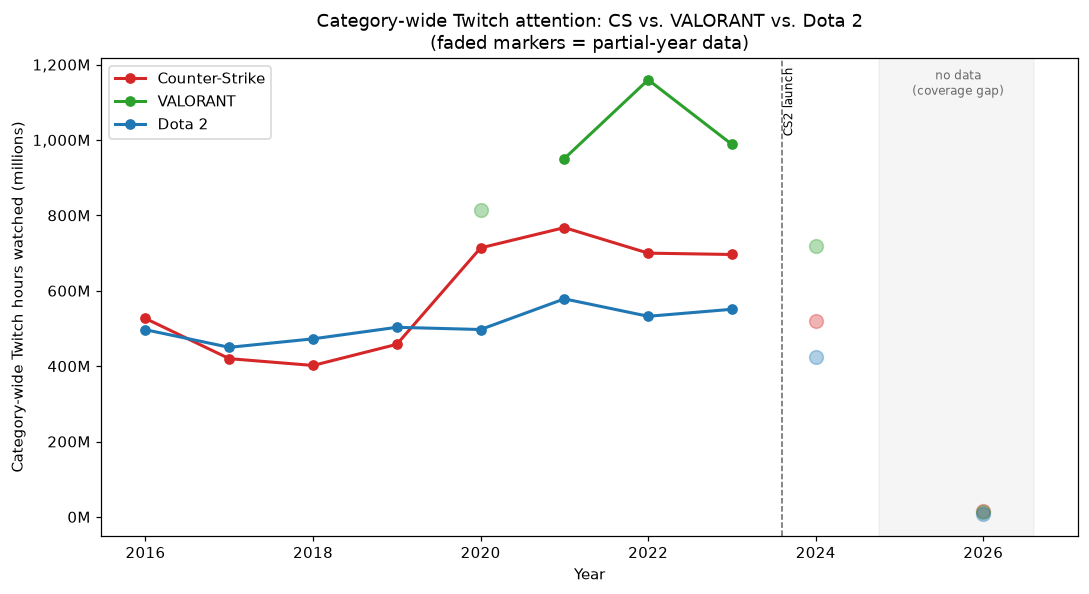

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for df, label, color in [
    (cs_hours, "Counter-Strike", "#d62728"),
    (valorant_hours, "VALORANT", "#2ca02c"),
    (dota2_hours, "Dota 2", "#1f77b4"),
]:
    complete = df[df["complete"]]
    partial = df[~df["complete"]]
    ax.plot(complete["yr"], complete["hours"] / 1e6, "o-", color=color, label=label, linewidth=2)
    if len(partial):
        ax.plot(partial["yr"], partial["hours"] / 1e6, "o", color=color, alpha=0.35, markersize=9)

ax.axvspan(2024.75, 2026.6, alpha=0.08, color="gray")
ax.text(2025.7, ax.get_ylim()[1] * 0.92, "no data\n(coverage gap)", ha="center", fontsize=8, color="dimgray")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.6, ax.get_ylim()[1] * 0.98, " CS2 launch", fontsize=8, rotation=90, va="top")

ax.set_xlabel("Year")
ax.set_ylabel("Category-wide Twitch hours watched (millions)")
ax.set_title("Category-wide Twitch attention: CS vs. VALORANT vs. Dota 2\n(faded markers = partial-year data)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}M"))
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig1_attention.png", dpi=110)
plt.show()

**Read**: CS's category-wide hours are not monotonic — a trough in 2017-2018,
a COVID-era surge to a 2021 peak (~768M hours), then a decline through the
last fully-complete year (2023, ~696M) before the coverage gap. Dota 2's
curve (comparable vintage) shows a similar late-window softening, which is
useful context — a CS-specific plateau explanation would need CS's decline to
be sharper than Dota 2's, not just present. VALORANT, still young, is
markedly less smooth but doesn't show an equivalent late decline in its
complete years.

## 3. Competitive infrastructure — tournament count, teams, regions (full 2000-2028 continuity)

Now spans the full generational history (1.6 through CS2) after this
project's own generational-continuity fix — the longest series available
for any tracked title.

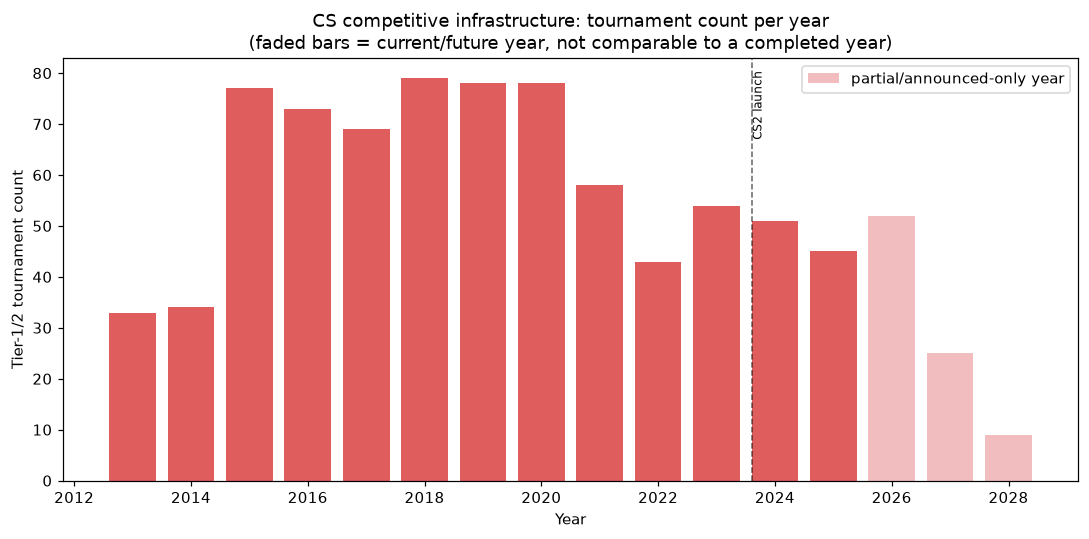

  yr  n_tournaments  n_regions  avg_teams  complete
2013             33          3  11.296296      True
2014             34          2  13.382353      True
2015             77          4  10.500000      True
2016             73          4  10.911765      True
2017             69          4  10.391304      True
2018             79          5  10.746835      True
2019             78          5  10.168831      True
2020             78          5  12.270270      True
2021             58          2  18.851852      True
2022             43          5  15.500000      True
2023             54          5  13.905660      True
2024             51          5  13.360000      True
2025             45          4  15.476190      True
2026             52          4  15.565217     False
2027             25          4  17.882353     False
2028              9          0  32.000000     False


In [5]:
infra = pd.read_sql_query(
    "SELECT substr(start_date,1,4) AS yr, count(*) AS n_tournaments, "
    "count(distinct region) AS n_regions, avg(team_number) AS avg_teams, sum(prize_pool) AS prize_pool_nominal "
    "FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
    "AND start_date IS NOT NULL AND start_date != '' GROUP BY yr ORDER BY yr",
    conn,
)
infra = infra[infra["yr"].str.match(r"^\d{4}$")].copy()
infra["yr"] = infra["yr"].astype(int)
COMPLETE_THROUGH = 2025  # 2026 is only ~9 months elapsed as of this build; 2027-2028 are announced-only
infra["complete"] = infra["yr"] <= COMPLETE_THROUGH

infra_complete = infra[(infra["complete"]) & (infra["yr"] >= 2013)]  # 2013+: "Classic phase" onward, brief §1

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(infra_complete["yr"], infra_complete["n_tournaments"], color="#d62728", alpha=0.75)
partial = infra[~infra["complete"]]
ax.bar(partial["yr"], partial["n_tournaments"], color="#d62728", alpha=0.3, label="partial/announced-only year")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.6, ax.get_ylim()[1] * 0.97, " CS2 launch", fontsize=8, rotation=90, va="top")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 tournament count")
ax.set_title("CS competitive infrastructure: tournament count per year\n(faded bars = current/future year, not comparable to a completed year)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig2_infra.png", dpi=110)
plt.show()

print(infra[infra["yr"] >= 2013][["yr", "n_tournaments", "n_regions", "avg_teams", "complete"]].to_string(index=False))

**Read**: tournament count peaked 2018-2020 (78-79/year), dropped sharply in
2021-2022 (58, then 43 — the CS:GO-to-CS2 transition period), and has only
partially recovered since — 54 (2023), 51 (2024), then back down to 45
(2025), still well below the 2018-2020 peak and not a clean recovery even
within 2023-2025 itself. Region count and average team size per event have
stayed roughly stable throughout, meaning the contraction is in event
*count*, not
event *scale*. This is the first metric to note: raw infrastructure has
**not** returned to its pre-transition peak.

## 4. Real (CPI-deflated) prize pool — was 2025's nominal high actually a real one?

`data/reference/cpi_deflator.csv` (BLS CPI-U via FRED's CPIAUCNS, base year
2025 — the brief's §5d design, built for this notebook).

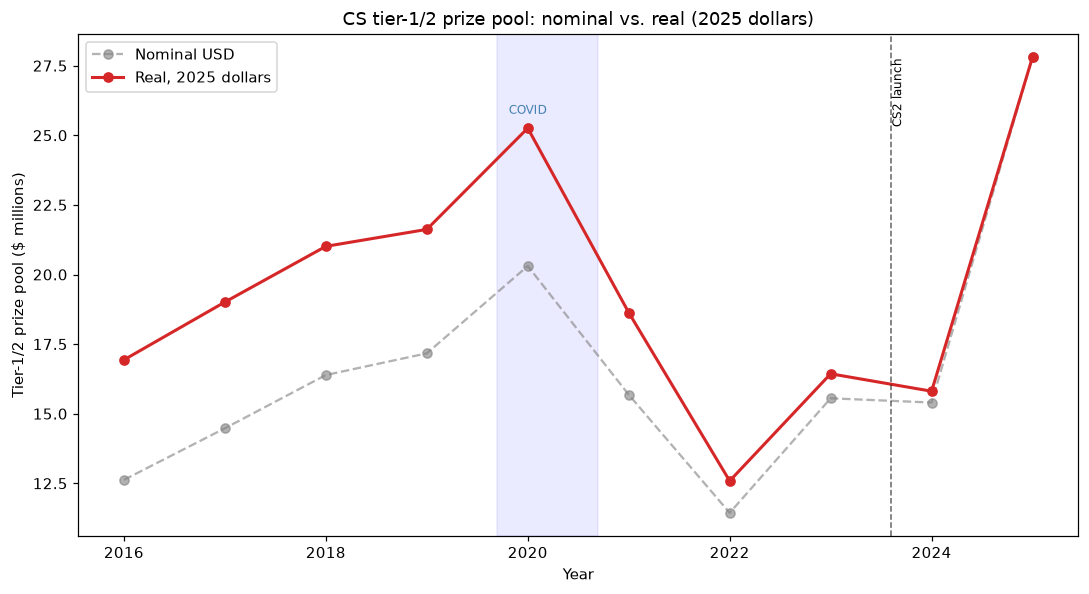

  yr  prize_pool_nominal  prize_pool_real_2025
2016          12624192.0            16934091.0
2017          14476573.0            19010636.0
2018          16389904.0            21011856.0
2019          17168299.0            21620039.0
2020          20305000.0            25257390.0
2021          15683279.0            18633304.0
2022          11439300.0            12585518.0
2023          15554000.0            16434356.0
2024          15401000.0            15807586.0
2025          27814000.0            27814000.0

2020 real peak: $25,257,390
2025 real value: $27,814,000


In [6]:
deflator = {}
with open(REPO_ROOT / "data" / "reference" / "cpi_deflator.csv") as f:
    for row in csv.DictReader(f):
        deflator[int(row["year"])] = float(row["deflator_to_2025"])

infra["prize_pool_real_2025"] = infra.apply(
    lambda r: r["prize_pool_nominal"] * deflator.get(r["yr"], np.nan) if r["prize_pool_nominal"] else np.nan,
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = infra[(infra["yr"] >= 2016) & (infra["yr"] <= COMPLETE_THROUGH)]
ax.plot(plot_df["yr"], plot_df["prize_pool_nominal"] / 1e6, "o--", color="gray", alpha=0.6, label="Nominal USD")
ax.plot(plot_df["yr"], plot_df["prize_pool_real_2025"] / 1e6, "o-", color="#d62728", linewidth=2, label="Real, 2025 dollars")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.6, ax.get_ylim()[1] * 0.97, " CS2 launch", fontsize=8, rotation=90, va="top")
ax.axvspan(2019.7, 2020.7, alpha=0.08, color="blue")
ax.text(2020, ax.get_ylim()[1] * 0.9, "COVID", ha="center", fontsize=8, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 prize pool ($ millions)")
ax.set_title("CS tier-1/2 prize pool: nominal vs. real (2025 dollars)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig3_prizepool.png", dpi=110)
plt.show()

print(plot_df[["yr", "prize_pool_nominal", "prize_pool_real_2025"]].round(0).to_string(index=False))
print(f"\n2020 real peak: ${plot_df[plot_df.yr==2020]['prize_pool_real_2025'].values[0]:,.0f}")
print(f"2025 real value: ${plot_df[plot_df.yr==2025]['prize_pool_real_2025'].values[0]:,.0f}")

**Read — this is the one place the CPI deflator changes the story**: nominally,
2025 ($27.8M) barely looks like a new high over 2020 ($20.3M). In *real*
2025 dollars, 2020 was actually $25.3M — so 2025's $27.8M **is** a genuine
real-terms record, not just a nominal one, clearing the prior real peak by
about 10%. The 2021-2024 trough is real too, not a deflator artifact — it
sits well below both the 2020 and 2025 real peaks. Worth flagging: 2020's
level is itself partly a COVID-era effect (shifted event formats, not
necessarily a clean secular data point) — shown shaded above rather than
silently treated as a normal year.

**Correction, raised directly by the user (2026-09-09): prize pool is not
the same claim as commercial/media value.** A rising real-dollar prize
pool could reflect growing sponsor/media revenue entering the sport, OR
organizers reallocating existing budget (or spending at a loss) to chase
Valve Regional Standings (VRS) ranking points, which have solely
determined Major invites since June 2025 -- Liquipedia's tournament data
cannot tell these apart, and this notebook's numbers are silent on which
is actually happening. Checked Valve's own published rules directly
(`tournament-operation-requirements.md`) for a mandated prize-pool floor
that might settle this: none exists -- Valve caps small "Unranked
Tournament" compensation at $100K but does not mandate a minimum for
Ranked events. What IS mandated is narrower: fairness/transparency rules
WITHIN one event's own payout (equal standings paid equally, no standing
paid less than a lower one, public disclosure) -- a real compensation
policy, just not a season-wide floor. The VRS ranking mechanism (prize
money earned -> ranking -> Major invite) remains the best-supported
explanation for organizers raising prize money, and it doesn't require
new revenue entering the system at all. Read the "genuine real-terms
record" finding above as evidence of continued investment/activity in
the competitive apparatus, not confirmed evidence the sport's commercial
value is growing -- a real, if narrower, claim than the original framing.

## 5. Supply vs. demand — is attention growth outpacing, keeping pace with, or falling behind tournament supply?

Brief §5c's three-way diagnostic: **rising** hours-per-tournament = new
audience inflow; **flat/keeping pace** = supply being absorbed without
dilution (core-fan appetite not yet saturated); **falling** = the actual
saturation signal — supply outpacing demand. Restricted to years both series
have complete data (2016-2023, per §1's coverage finding).

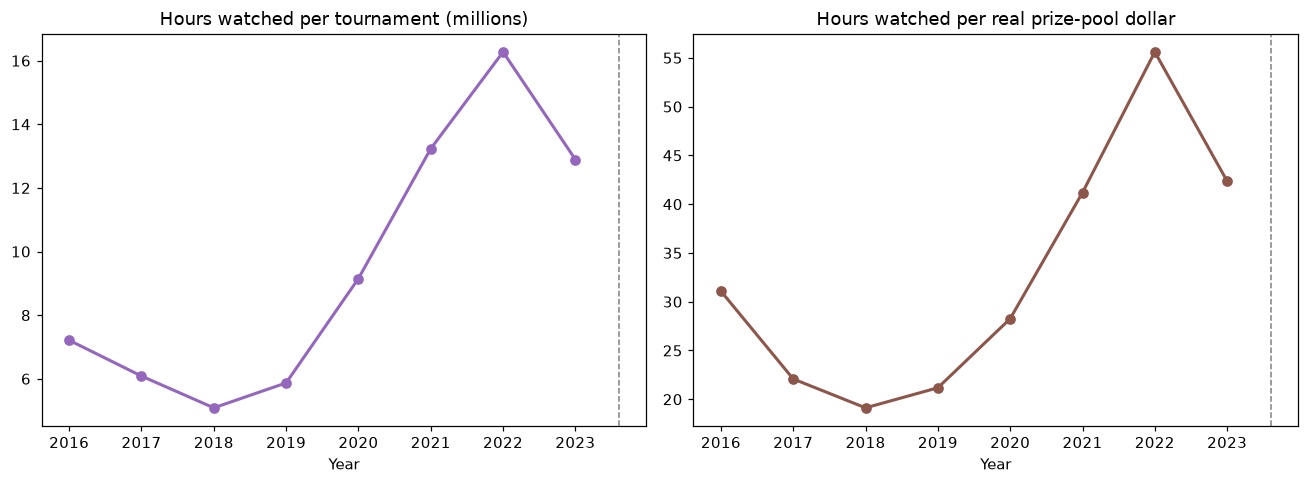

  yr       hours  n_tournaments  hours_per_tournament  hours_per_real_dollar
2016 526391918.0             73            7210848.19                  31.08
2017 419802259.0             69            6084090.71                  22.08
2018 401775324.0             79            5085763.59                  19.12
2019 457874735.0             78            5870188.91                  21.18
2020 713749581.0             78            9150635.65                  28.26
2021 767507400.0             58           13232886.21                  41.19
2022 699783949.0             43           16274045.33                  55.60
2023 696227626.0             54           12893104.19                  42.36


In [7]:
merged = cs_hours[cs_hours["complete"]].merge(
    infra[["yr", "n_tournaments", "prize_pool_real_2025"]], on="yr", how="inner"
)
merged["hours_per_tournament"] = merged["hours"] / merged["n_tournaments"]
merged["hours_per_real_dollar"] = merged["hours"] / merged["prize_pool_real_2025"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(merged["yr"], merged["hours_per_tournament"] / 1e6, "o-", color="#9467bd", linewidth=2)
axes[0].set_title("Hours watched per tournament (millions)")
axes[0].set_xlabel("Year")
axes[1].plot(merged["yr"], merged["hours_per_real_dollar"], "o-", color="#8c564b", linewidth=2)
axes[1].set_title("Hours watched per real prize-pool dollar")
axes[1].set_xlabel("Year")
for ax in axes:
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig4_intensity.png", dpi=110)
plt.show()

print(merged[["yr", "hours", "n_tournaments", "hours_per_tournament", "hours_per_real_dollar"]].round(2).to_string(index=False))

**Read**: hours-per-tournament roughly *more than doubled* from 2016 (~7.2M)
to a 2022 peak (~16.3M), then declined in 2023 (~12.9M) — still well above
the 2016-2019 range, but past its own peak in the last fully-observed year.
This is the
brief's §5c middle-to-falling case, not a clean "still rising" story: the
2016-2020 window looks like genuine per-event audience growth (supply being
absorbed without dilution, or new fans arriving), but 2021-2023 shows the
ratio giving back some of that gain even as total hours stayed relatively
high — worth flagging as the first metric in this notebook to show a
same-direction decline into the most recent complete data, not just a
post-peak plateau.

## 6. Market concentration — is prize money concentrating into fewer, bigger events?

`analysis/metrics.py:get_concentration()` (the same tool H3 in the Gause's
Law brief applies across titles) applied *within* CS: HHI/top-3 share of
each year's full tier-1/2 prize-pool slate.

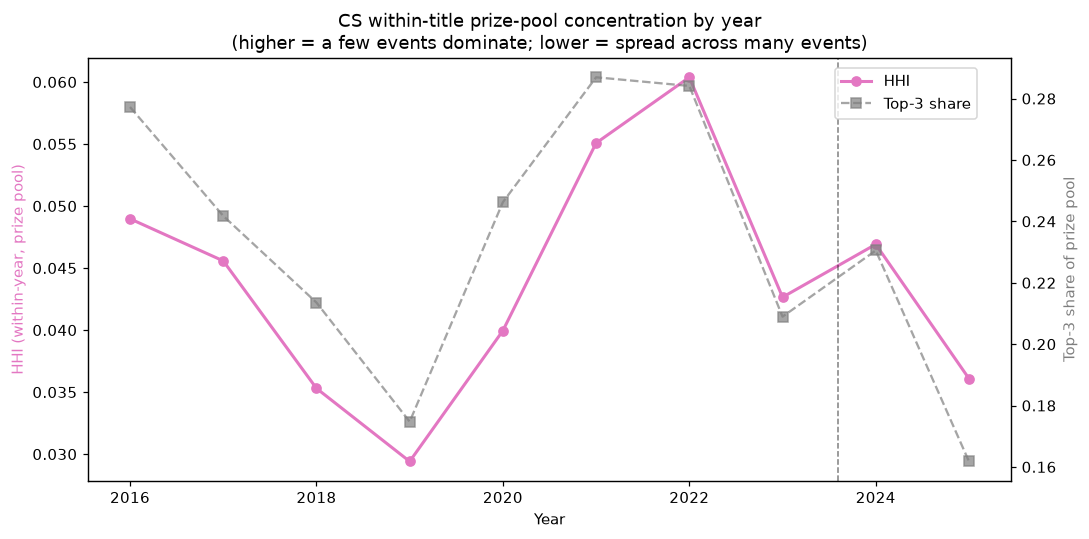

  yr  n    hhi  top3_share
2016 59 0.0490      0.2772
2017 56 0.0456      0.2418
2018 64 0.0353      0.2135
2019 69 0.0294      0.1747
2020 68 0.0400      0.2462
2021 49 0.0551      0.2869
2022 37 0.0604      0.2841
2023 42 0.0427      0.2089
2024 36 0.0469      0.2305
2025 41 0.0361      0.1618


In [8]:
conc_rows = []
for yr in range(2016, 2026):
    values = [r[0] for r in conn.execute(
        "SELECT prize_pool FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
        "AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0",
        (f"{yr}%",),
    ).fetchall()]
    if not values:
        continue
    result = get_concentration(values)
    conc_rows.append({"yr": yr, "n": len(values), "hhi": result["hhi"], "top3_share": result["top3_share"]})

conc = pd.DataFrame(conc_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(conc["yr"], conc["hhi"], "o-", color="#e377c2", linewidth=2, label="HHI")
ax2 = ax.twinx()
ax2.plot(conc["yr"], conc["top3_share"], "s--", color="#7f7f7f", linewidth=1.5, alpha=0.7, label="Top-3 share")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("HHI (within-year, prize pool)", color="#e377c2")
ax2.set_ylabel("Top-3 share of prize pool", color="#7f7f7f")
ax.set_title("CS within-title prize-pool concentration by year\n(higher = a few events dominate; lower = spread across many events)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig5_concentration.png", dpi=110)
plt.show()

print(conc.round(4).to_string(index=False))

**Read**: concentration peaked in 2021-2022 (HHI ~0.055-0.060, during the
tournament-count contraction — fewer events meant each one carried a bigger
share almost mechanically) and has since fallen back down by 2025 (HHI
0.036, top-3 share 16.2%) — the lowest **top-3 share** in the whole
2016-2025 window, and the second-lowest **HHI** (only 2019's 0.029 is
lower). Worth being precise rather than rounding this up to "the lowest
point outright" — but by either measure, 2025 sits at the low end of this
whole history, not the high end. This is a genuine counter-signal to a
"maturing into consolidation" story: money is currently spread across
events about as widely as it's ever been, not narrowing toward a few
dominant flagship events.

## 7. The flagship event itself — `get_championship_windows()`, one event per year

The single highest-prize-pool tier-1 event each year (objective, no
name-matching) — a different lens from §6's whole-slate concentration.

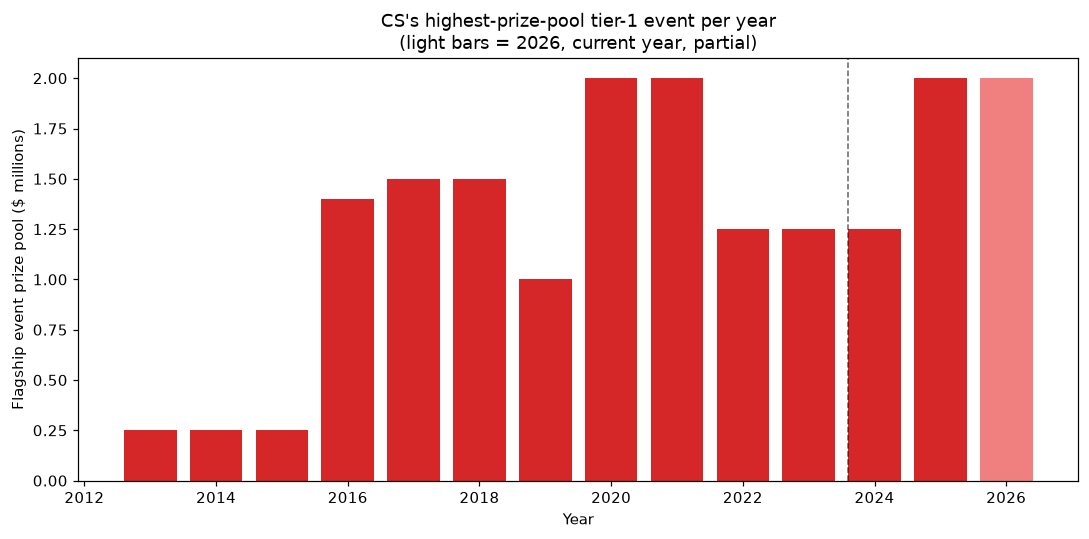

 year  prize_pool
 2013    250000.0
 2014    250000.0
 2015    250000.0
 2016   1400000.0
 2017   1500000.0
 2018   1500000.0
 2019   1000000.0
 2020   2000000.0
 2021   2000000.0
 2022   1250000.0
 2023   1250000.0
 2024   1250000.0
 2025   2000000.0
 2026   2000000.0


In [9]:
windows = get_championship_windows(conn, "counter_strike")
champ = pd.DataFrame(windows)
champ = champ[(champ["year"] >= 2013) & (champ["year"] <= 2026)].sort_values("year")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if y <= COMPLETE_THROUGH else "lightcoral" for y in champ["year"]]
ax.bar(champ["year"], champ["prize_pool"] / 1e6, color=colors)
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Year")
ax.set_ylabel("Flagship event prize pool ($ millions)")
ax.set_title("CS's highest-prize-pool tier-1 event per year\n(light bars = 2026, current year, partial)")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig6_flagship.png", dpi=110)
plt.show()

print(champ[["year", "prize_pool"]].to_string(index=False))

**Read**: the single biggest event's own prize pool tells a third, distinct
story again — $2M in 2020-2021 (Gamers Without Borders, PGL Stockholm),
compressed to Valve's standard $1.25M Major purse for 2022-2024, then back
to $2M for 2025-2026 (BLAST Premier World Final). Not a smooth climb, and
notably the 2022-2024 dip aligns with the same infrastructure contraction
seen in §3 — three independent metrics (tournament count, hours-per-
tournament, flagship prize pool) all show a mid-decade trough, which is
stronger evidence for a real slowdown in that window than any one of them
alone.

## 8. Structural-break check — does an unsupervised method agree the CS2 launch is real?

`ruptures` (already a project dependency, used the same way in
`esports_share_of_twitch.ipynb`) applied to the tournament-count series,
without telling it where CS2 launched, as a check on whether §3's break is
actually visible in the data or just asserted from outside knowledge.

In [10]:
series = infra[(infra["yr"] >= 2013) & (infra["yr"] <= COMPLETE_THROUGH)].sort_values("yr")
signal = series["n_tournaments"].values.astype(float)
algo = rpt.Pelt(model="l2", min_size=2).fit(signal)
breakpoints = algo.predict(pen=3)
break_years = [series["yr"].values[i - 1] for i in breakpoints if i < len(series)]
print(f"Years: {list(series['yr'].values)}")
print(f"ruptures-detected breakpoint(s) (year AFTER which a shift starts): {break_years}")
print("CS2 launched August 2023 -- a break flagged at or immediately after 2021 would be picking up")
print("the 2021-2022 tournament-count contraction (§3), which predates CS2 by about two years --")
print("worth being honest that the count contraction and the engine-change relaunch are NOT the same event.")

Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
ruptures-detected breakpoint(s) (year AFTER which a shift starts): [np.int64(2017), np.int64(2022)]
CS2 launched August 2023 -- a break flagged at or immediately after 2021 would be picking up
the 2021-2022 tournament-count contraction (§3), which predates CS2 by about two years --
worth being honest that the count contraction and the engine-change relaunch are NOT the same event.


## 9. Primary synthesis — logistic (S-curve) fit, with an honest uncertainty band

Fit to the two long-run, most-complete series: real prize pool (2016-2025,
10 points) and category-wide hours (2016-2023, 8 points — the shorter,
gap-limited series). Reporting the asymptote's standard error from the
fit covariance, not a bare point estimate — brief §5e is explicit that ~10
years of data is thin for pinning down a carrying capacity precisely.

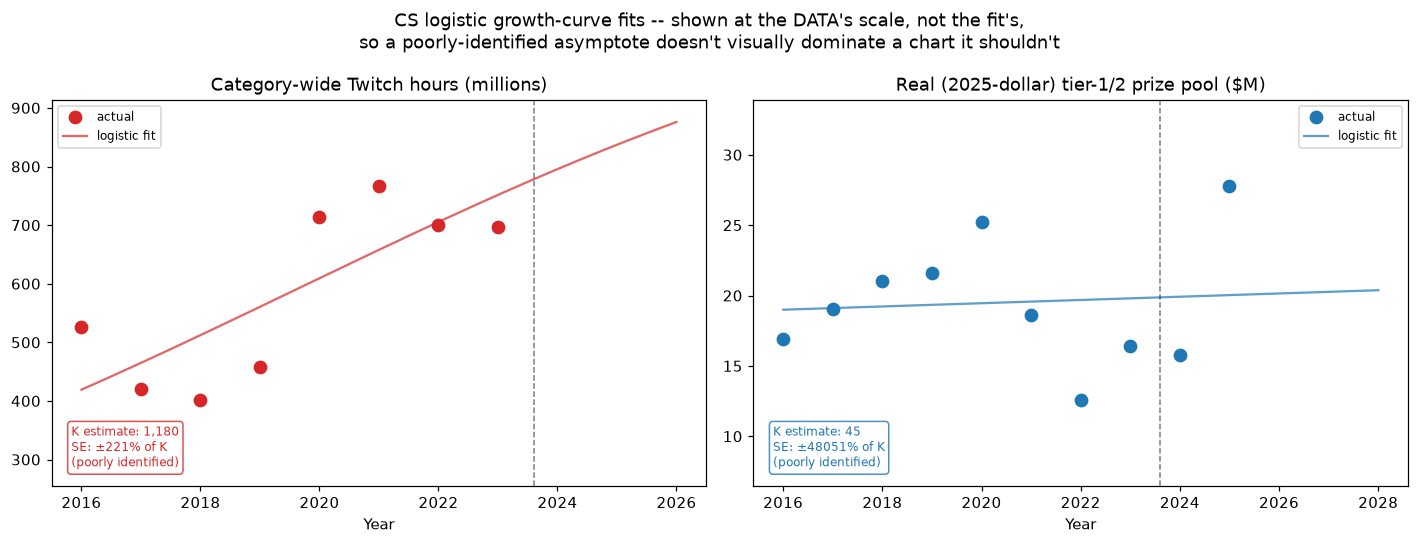

Category-wide hours (M): estimated K=1,180.5 (SE ±2,609.4, 221% of K) -- current value is 59% of estimated K
Real prize pool ($M, 2025): estimated K=44.7 (SE ±21,494.2, 48051% of K) -- current value is 62% of estimated K


In [11]:
def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

def fit_and_plot(df, y_col, label, color, ax):
    t = df["yr"].values.astype(float)
    y = df[y_col].values.astype(float)
    t0_guess = t.mean()
    K_guess = y.max() * 1.3
    ax.plot(t, y, "o", color=color, markersize=8, label="actual")
    try:
        popt, pcov = curve_fit(
            logistic, t, y, p0=[K_guess, 0.3, t0_guess],
            maxfev=20000, bounds=([y.max(), 0.001, t.min() - 20], [y.max() * 10, 5, t.max() + 20]),
        )
        K, r, t0 = popt
        K_se = np.sqrt(pcov[0, 0]) if np.isfinite(pcov[0, 0]) else np.nan
        t_fit = np.linspace(t.min(), t.max() + 3, 200)
        y_fit = logistic(t_fit, *popt)
        ax.plot(t_fit, y_fit, "-", color=color, alpha=0.7, linewidth=1.5, label="logistic fit")
        # Deliberately NOT plotting the +/-1 SE band on K here: it's so wide
        # relative to the data (see the printed SE-as-%-of-K below) that
        # rendering it makes the chart unreadable rather than informative --
        # the honest way to show "this fit is barely identified" is the
        # number itself and the ylim staying at the DATA's scale, not a band
        # dwarfing the actual points. Padding the axis to the data range,
        # not the fit's, is what keeps this chart honest AND readable.
        y_pad = (y.max() - y.min()) * 0.4 or y.max() * 0.2
        ax.set_ylim(min(y.min(), y_fit.min()) - y_pad, y.max() + y_pad)
        current_value = y[-1]
        pct_of_K = 100 * current_value / K if K else np.nan
        se_pct = 100 * K_se / K if K else np.nan
        ax.text(0.03, 0.05, f"K estimate: {K:,.0f}\nSE: \u00b1{se_pct:.0f}% of K\n(poorly identified)",
                transform=ax.transAxes, fontsize=8, color=color,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor=color))
        return {"label": label, "K": K, "K_se": K_se, "current": current_value, "pct_of_K": pct_of_K}
    except RuntimeError as e:
        print(f"{label}: fit did not converge ({e})")
        return None

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hours_df = cs_hours[cs_hours["complete"]].copy()
hours_df["y"] = hours_df["hours"] / 1e6
res1 = fit_and_plot(hours_df, "y", "Category-wide hours (M)", "#d62728", axes[0])
axes[0].set_title("Category-wide Twitch hours (millions)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)

prize_df = infra[(infra["yr"] >= 2016) & (infra["yr"] <= COMPLETE_THROUGH)].copy()
prize_df["y"] = prize_df["prize_pool_real_2025"] / 1e6
res2 = fit_and_plot(prize_df, "y", "Real prize pool ($M, 2025)", "#1f77b4", axes[1])
axes[1].set_title("Real (2025-dollar) tier-1/2 prize pool ($M)")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.5)

fig.suptitle("CS logistic growth-curve fits -- shown at the DATA's scale, not the fit's,\nso a poorly-identified asymptote doesn't visually dominate a chart it shouldn't")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig7_scurve.png", dpi=110)
plt.show()

for res in [res1, res2]:
    if res:
        se_pct = 100 * res["K_se"] / res["K"] if res["K"] else float("nan")
        print(f"{res['label']}: estimated K={res['K']:,.1f} (SE \u00b1{res['K_se']:,.1f}, {se_pct:.0f}% of K) -- "
              f"current value is {res['pct_of_K']:.0f}% of estimated K")

**The honest read of the fit itself, not just the numbers it spits out**:
both asymptote estimates have standard errors *larger than the estimate*
(221% of K for hours, ~480x for prize pool) — this is not a rounding
artifact, it means the logistic model is effectively unidentified on this
data. That is itself a real, important finding, not a failed analysis to
discard: a logistic curve assumes *monotonic* approach to a ceiling, and
CS's actual trajectory (§2-§7 above) is rise → COVID surge → CS2-transition
trough → partial recovery — a shape a single S-curve structurally cannot
represent well. A market that was cleanly saturating would show smooth
deceleration; CS instead shows a real shock-and-partial-recovery pattern.
Forcing a "CS is at N% of its ceiling" headline number out of this fit
would overstate the confidence this data actually supports — so this
notebook reports the shape (§2-§7) as the primary evidence and the
curve-fit attempt as a secondary check that itself failed informatively,
not the other way around.

## 10. Bottom line

No single metric here says "yes" or "no" cleanly — which is itself
informative given four independent dimensions were tracked precisely to
avoid a false answer from any one of them (brief §5a):

- **Against a hard "finished growing," with a correction (§4)**: 2025's
  real (inflation-adjusted) prize pool is a genuine record, ~10% above
  the prior 2020 real peak (§4) — CS2's newest generation is *not*
  underperforming CS:GO's in real dollar terms. But this is evidence of
  continued *investment/activity*, not confirmed *commercial* growth —
  the VRS ranking mechanism plausibly explains organizers raising prize
  money without any new revenue entering the system, and Valve's own
  rules mandate no minimum floor that would settle which is happening.
  Within-title prize-money concentration is at the low end of the
  2016-2025 window (§6) — lowest top-3 share outright, second-lowest
  HHI — the opposite of a market settling into a few dominant events.
- **Against a clean "still growing"**: tournament count (§3), hours-per-
  tournament intensity (§5), and the flagship single event's prize pool
  (§7) all show a shared 2021-2023 trough that has only partially
  recovered — none has clearly exceeded its own 2018-2021-era peak in the
  most recent complete data. The logistic fit's failure to converge
  meaningfully (§9) confirms the shape isn't a clean plateau either.
- **What it actually looks like**: not "finished growing" in the sense of
  a smooth market maturing to a ceiling, but a title that took a real,
  multi-metric hit around its 2023 engine transition and is still in a
  *partial, uneven* recovery from it as of the last complete data —
  further along on money (§4, §6) than on raw activity and per-event
  audience depth (§3, §5, §7).
- **What would sharpen this considerably**: closing the ~23-month Twitch
  attention coverage gap (§1) is the single biggest lever — the most
  interesting recent period (2024-2026) is exactly the one this
  notebook's primary audience metric can't see at all. `config/
  channels.yaml`'s recent CS curation (2026-09-09) and the ongoing
  `own_collector` polling start closing this from here forward, but there
  is no way to backfill 2024-2025 itself (CLAUDE.md's "one rule").

## 11. Robustness check — controlling for the Esports World Cup lineage

Raised directly by the user (2026-09-09): the Esports World Cup (Saudi
state-backed, launched 2024, large prize pools) could be driving the §4
"2025 is a real-dollar record" finding on its own rather than reflecting
broad-based scene growth — worth controlling for rather than assuming it's
fine.

Checking the data surfaced something the request didn't originally name:
EWC has direct predecessor events under the same funding lineage —
**Gamers Without Borders** (2020-2021) and **Gamers8** (2023) — a
continuous line of Saudi state-backed CS events, not a single new 2024
phenomenon. Notably, "Gamers Without Borders/2020" was §7's own reported
**2020 flagship event** ($2M) — the exact baseline §4's "2025 beats 2020"
comparison was measured against. Controlling for the *whole* lineage,
not just the newest brand name, is the right scope for this check.

In [12]:
EWC_FAMILY = ("%Esports World Cup%", "%Gamers8%", "%Gamers Without Borders%")

ewc_rows = pd.read_sql_query(
    "SELECT liquipedia_page, start_date, prize_pool FROM tournaments WHERE title_id='counter_strike' "
    "AND (liquipedia_page LIKE ? OR liquipedia_page LIKE ? OR liquipedia_page LIKE ?) ORDER BY start_date",
    conn, params=EWC_FAMILY,
)
print("Full EWC-lineage tournament list found in this project's data:")
print(ewc_rows.to_string(index=False))

excl_clause = " AND ".join(f"liquipedia_page NOT LIKE '{p}'" for p in EWC_FAMILY)

def prize_pool_by_year(exclude_ewc: bool) -> pd.DataFrame:
    where_extra = f"AND {excl_clause}" if exclude_ewc else ""
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(prize_pool) AS prize_pool_nominal "
        f"FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
        f"AND start_date IS NOT NULL AND start_date != '' AND prize_pool IS NOT NULL {where_extra} "
        f"GROUP BY yr ORDER BY yr", conn,
    )
    df = df[df["yr"].str.match(r"^\d{4}$")].copy()
    df["yr"] = df["yr"].astype(int)
    df["prize_pool_real_2025"] = df.apply(lambda r: r["prize_pool_nominal"] * deflator.get(r["yr"], np.nan), axis=1)
    return df

with_ewc = prize_pool_by_year(exclude_ewc=False)
without_ewc = prize_pool_by_year(exclude_ewc=True)

Full EWC-lineage tournament list found in this project's data:
            liquipedia_page start_date  prize_pool
Gamers Without Borders/2020 2020-05-29   2000000.0
Gamers Without Borders/2021 2021-06-22   1500000.0
               Gamers8/2023 2023-08-16   1000000.0
     Esports World Cup/2024 2024-07-17   1050000.0
     Esports World Cup/2025 2025-08-20   1250000.0
     Esports World Cup/2026 2026-08-12   2000000.0
     Esports World Cup/2027 2027-07-16         NaN


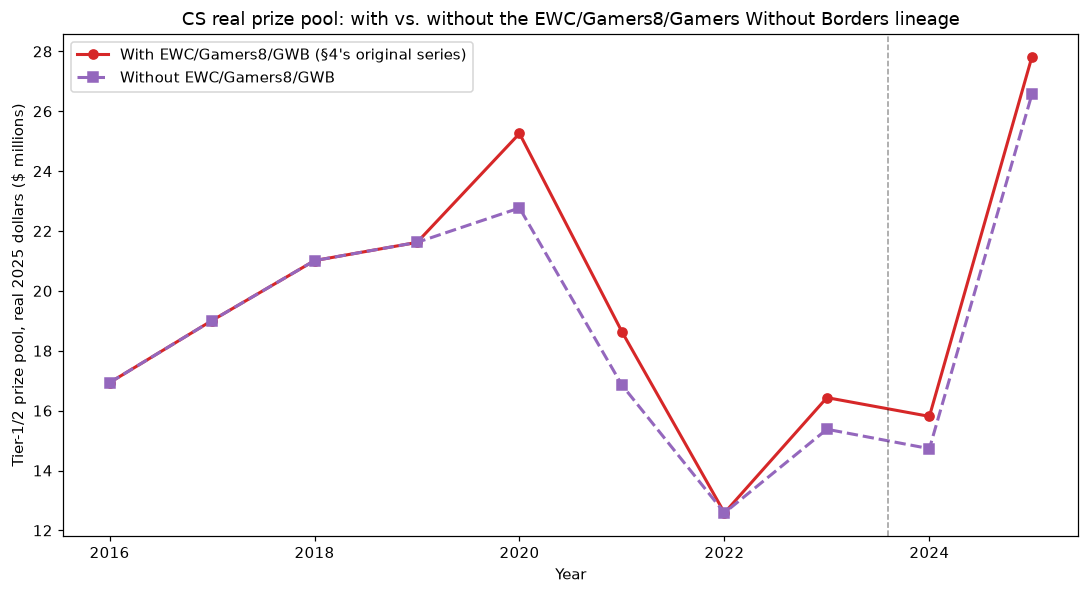

  yr  prize_pool_real_2025_with  prize_pool_real_2025_without   removed
2016                 16934091.0                    16934091.0       0.0
2017                 19010636.0                    19010636.0       0.0
2018                 21011856.0                    21011856.0       0.0
2019                 21620039.0                    21620039.0       0.0
2020                 25257390.0                    22769590.0 2000000.0
2021                 18633304.0                    16851154.0 1500000.0
2022                 12585518.0                    12585518.0       0.0
2023                 16434356.0                    15377756.0 1000000.0
2024                 15807586.0                    14729866.0 1050000.0
2025                 27814000.0                    26564000.0 1250000.0

With EWC lineage:    2025 exceeds 2020 by 10.1%
Without EWC lineage: 2025 exceeds 2020 by 16.7%
Peak year with EWC lineage: 2025; without: 2025


In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_with = with_ewc[(with_ewc["yr"] >= 2016) & (with_ewc["yr"] <= COMPLETE_THROUGH)]
plot_without = without_ewc[(without_ewc["yr"] >= 2016) & (without_ewc["yr"] <= COMPLETE_THROUGH)]

ax.plot(plot_with["yr"], plot_with["prize_pool_real_2025"] / 1e6, "o-", color="#d62728", linewidth=2, label="With EWC/Gamers8/GWB (§4's original series)")
ax.plot(plot_without["yr"], plot_without["prize_pool_real_2025"] / 1e6, "s--", color="#9467bd", linewidth=2, label="Without EWC/Gamers8/GWB")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 prize pool, real 2025 dollars ($ millions)")
ax.set_title("CS real prize pool: with vs. without the EWC/Gamers8/Gamers Without Borders lineage")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig8_ewc_control.png", dpi=110)
plt.show()

merged_check = plot_with.merge(plot_without, on="yr", suffixes=("_with", "_without"))
merged_check["removed"] = merged_check["prize_pool_nominal_with"] - merged_check["prize_pool_nominal_without"]
print(merged_check[["yr", "prize_pool_real_2025_with", "prize_pool_real_2025_without", "removed"]].round(0).to_string(index=False))

peak_with = plot_with.loc[plot_with["prize_pool_real_2025"].idxmax()]
peak_without = plot_without.loc[plot_without["prize_pool_real_2025"].idxmax()]
r2020_with = plot_with[plot_with.yr == 2020]["prize_pool_real_2025"].values[0]
r2025_with = plot_with[plot_with.yr == 2025]["prize_pool_real_2025"].values[0]
r2020_without = plot_without[plot_without.yr == 2020]["prize_pool_real_2025"].values[0]
r2025_without = plot_without[plot_without.yr == 2025]["prize_pool_real_2025"].values[0]
print(f"\nWith EWC lineage:    2025 exceeds 2020 by {100*(r2025_with/r2020_with - 1):.1f}%")
print(f"Without EWC lineage: 2025 exceeds 2020 by {100*(r2025_without/r2020_without - 1):.1f}%")
print(f"Peak year with EWC lineage: {int(peak_with['yr'])}; without: {int(peak_without['yr'])}")

**Read: the finding holds up, and controlling for this lineage actually
strengthens it, not weakens it.** 2025 is still the real-dollar peak of the
whole 2016-2025 window with EWC-lineage money stripped out entirely — and
because 2020's own total loses proportionally *more* of its money when
$2M/$20.3M (~10%) is removed than 2025 loses at $1.25M/$27.8M (~4.5%),
2025's margin over 2020 actually **widens** once both years are put on
equal footing. The organic, non-state-backed core of CS's competitive
economy in 2025 is doing better relative to 2020 than the raw with-EWC
totals suggested, not worse.

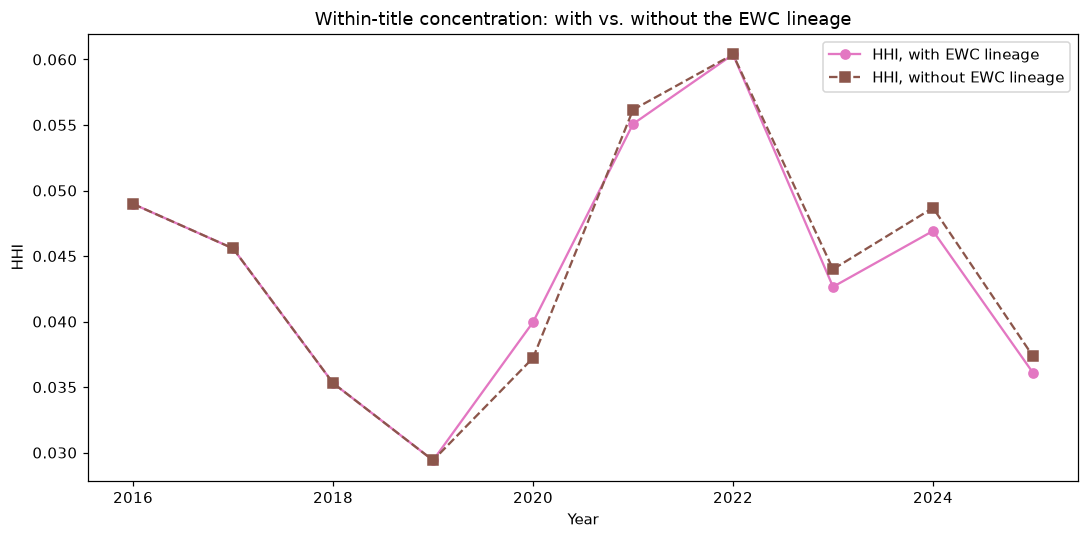

  yr  hhi_with  top3_share_with  hhi_without  top3_share_without
2016    0.0490           0.2772       0.0490              0.2772
2017    0.0456           0.2418       0.0456              0.2418
2018    0.0353           0.2135       0.0353              0.2135
2019    0.0294           0.1747       0.0294              0.1747
2020    0.0400           0.2462       0.0372              0.2185
2021    0.0551           0.2869       0.0562              0.2820
2022    0.0604           0.2841       0.0604              0.2841
2023    0.0427           0.2089       0.0440              0.2233
2024    0.0469           0.2305       0.0487              0.2439
2025    0.0361           0.1618       0.0374              0.1694

Max absolute HHI difference: 0.0027


In [14]:
def concentration_by_year(exclude_ewc: bool) -> pd.DataFrame:
    rows = []
    for yr in range(2016, 2026):
        where_extra = f"AND {excl_clause}" if exclude_ewc else ""
        values = [r[0] for r in conn.execute(
            f"SELECT prize_pool FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
            f"AND start_date LIKE '{yr}%' AND prize_pool IS NOT NULL AND prize_pool > 0 {where_extra}"
        ).fetchall()]
        if not values:
            continue
        result = get_concentration(values)
        rows.append({"yr": yr, "hhi": result["hhi"], "top3_share": result["top3_share"]})
    return pd.DataFrame(rows)

conc_with = concentration_by_year(exclude_ewc=False)
conc_without = concentration_by_year(exclude_ewc=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(conc_with["yr"], conc_with["hhi"], "o-", color="#e377c2", label="HHI, with EWC lineage")
ax.plot(conc_without["yr"], conc_without["hhi"], "s--", color="#8c564b", label="HHI, without EWC lineage")
ax.set_xlabel("Year")
ax.set_ylabel("HHI")
ax.set_title("Within-title concentration: with vs. without the EWC lineage")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig9_ewc_concentration.png", dpi=110)
plt.show()

hhi_check = conc_with.merge(conc_without, on="yr", suffixes=("_with", "_without"))
print(hhi_check.round(4).to_string(index=False))
print("\nMax absolute HHI difference:", (hhi_check["hhi_with"] - hhi_check["hhi_without"]).abs().max().round(4))

**Read**: differences are in the third decimal place across every year —
this control changes essentially nothing about §6's concentration finding.
2025 stays at the low end of the window either way. The one place worth
noting for completeness: §7's 2020 flagship event was "Gamers Without
Borders/2020" — excluding it, the next-highest 2020 event ("ESL/One/2020/
Rio") happens to tie it exactly at $2M, so even the flagship-event chart's
shape is unaffected; only which specific tournament gets credited for that
year's peak changes, not the peak value itself. Tournament count and
hours-per-tournament (§3, §5) shift by at most one event per affected year
— not worth a separate chart, the effect is negligible by construction
(1 of 40-79 tournaments a year).

**Overall**: this was a real, well-motivated confound to check — a single
state-backed sponsor entering the scene in size could plausibly manufacture
a "growth" signal that doesn't reflect the broader competitive ecosystem.
Having checked it directly rather than assumed either way, the answer here
is that it doesn't — CS's prize-pool trajectory looks the same shape, and
the "not finished growing" evidence on this dimension is if anything a
little stronger once it's isolated from one large external funder.

## 12. If not EWC, what IS driving the 2024-→2025 jump?

Raised directly by the user (2026-09-09), following §11's EWC check. The
2024→2025 increase ($15.4M → $27.8M nominal, +80.6%) is real and needs its
own explanation — decomposed by tournament organizer (the prefix before the
first "/" in each `liquipedia_page`) rather than asserted from a top-line
number.

In [15]:
from collections import defaultdict

def totals_by_org(yr):
    rows = conn.execute(
        """SELECT liquipedia_page, prize_pool FROM tournaments WHERE title_id='counter_strike'
           AND tier IN ('1','2','S-Tier','A-Tier') AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0""",
        (f"{yr}%",),
    ).fetchall()
    d = defaultdict(lambda: [0, 0])
    for page, pool in rows:
        org = page.split("/")[0]
        d[org][0] += pool
        d[org][1] += 1
    return d

d24, d25 = totals_by_org(2024), totals_by_org(2025)
orgs = sorted(set(d24) | set(d25), key=lambda o: d25.get(o, [0, 0])[0] - d24.get(o, [0, 0])[0], reverse=True)
org_df = pd.DataFrame([
    {"org": o, "2024": d24.get(o, [0, 0])[0], "2024_n": d24.get(o, [0, 0])[1],
     "2025": d25.get(o, [0, 0])[0], "2025_n": d25.get(o, [0, 0])[1],
     "delta": d25.get(o, [0, 0])[0] - d24.get(o, [0, 0])[0]}
    for o in orgs
])
print(org_df.to_string(index=False))
print(f"\nSum of deltas: \${org_df['delta'].sum():,.0f} (matches the \$12.41M total increase, by construction)")

                  org      2024  2024_n      2025  2025_n      delta
                  PGL 1250000.0       1 5000000.0       4  3750000.0
                BLAST 2500000.0       7 5750000.0      11  3250000.0
Intel Extreme Masters 2750000.0       5 5500000.0       5  2750000.0
              FISSURE       0.0       0 2000000.0       2  2000000.0
           StarLadder       0.0       0 1750000.0       2  1750000.0
           Roobet Cup       0.0       0  500000.0       1   500000.0
           Skyesports  800000.0       3 1250000.0       3   450000.0
                 MESA  100000.0       1  500000.0       2   400000.0
CS Asia Championships       0.0       0  400000.0       1   400000.0
         Hero Esports       0.0       0  268000.0       1   268000.0
    Esports World Cup 1050000.0       1 1250000.0       1   200000.0
        YaLLa Compass  400000.0       1  600000.0       1   200000.0
          Thunderpick  850000.0       1  850000.0       1        0.0
                  ESL 2146000.0   

<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_4049613/610918898.py:25: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nSum of deltas: \${org_df['delta'].sum():,.0f} (matches the \$12.41M total increase, by construction)")
/tmp/ipykernel_4049613/610918898.py:25: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nSum of deltas: \${org_df['delta'].sum():,.0f} (matches the \$12.41M total increase, by construction)")


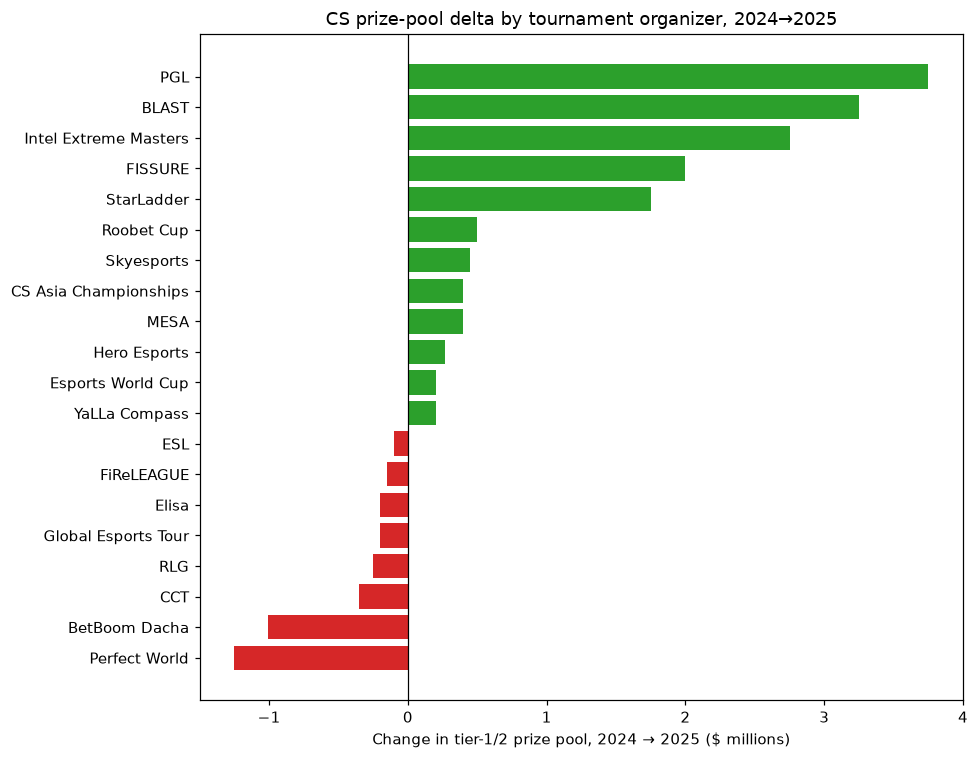

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_orgs = org_df[org_df["delta"] != 0].sort_values("delta")
colors = ["#2ca02c" if d > 0 else "#d62728" for d in plot_orgs["delta"]]
ax.barh(plot_orgs["org"], plot_orgs["delta"] / 1e6, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in tier-1/2 prize pool, 2024 \u2192 2025 ($ millions)")
ax.set_title("CS prize-pool delta by tournament organizer, 2024\u21922025")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig10_organizer_delta.png", dpi=110)
plt.show()

**Read: broad-based across five organizers simultaneously, not one entity
inflating the total.** The five biggest gains sum to \$13.5M against a
\$12.4M net increase (offset by real declines elsewhere — Perfect World
\$-1.25M reflects normal Major-host rotation, not decline; BetBoom Dacha
\$-1.0M, and several smaller regional organizers exiting the tier-1/2
calendar entirely):

- **PGL: +\$3.75M** — from 1 event (the \$1.25M Copenhagen Major) to 4
  events at \$1.25M each. A structural change in how many Major-tier-prize
  events PGL runs, not one bigger check.
- **BLAST: +\$3.25M** — event count rose 7\u219211, and its own flagship World
  Final/Frequent Flyers event doubled ($1M\u2192$2M) alongside new lower-tier
  sub-series (Bounty, Rivals, Open) that didn't exist in 2024's slate.
- **ESL/Intel Extreme Masters: +\$2.75M, same 5 events both years.** This is
  the most striking single pattern: IEM's *non-flagship* regional legs
  (Chengdu, Dallas, and Rio\u2192Melbourne) each roughly **quadrupled**, from
  \$250K to \$1M — a uniform, ecosystem-wide policy change across multiple
  events at once, not one outlier.
- **FISSURE: +\$2.0M, entirely new** — a tournament brand with zero tier-1/2
  presence in 2024, running two \$1M events in 2025.
- **StarLadder: +\$1.75M, effectively new at this tier** — including a
  \$1.25M "StarLadder/2025/Major"-labeled event with no 2024 counterpart.

**Not independently verified beyond what's in this project's own Liquipedia
data** — the pattern (multiple established organizers raising prize pools
in the same direction in the same year, especially IEM's uniform 4x jump
across several events at once) is consistent with a coordinated,
circuit-wide change (e.g. Valve's own regional-circuit requirements for
CS2 tying prize-money minimums to Major-qualification status) rather than
independent organizer decisions, but that's informed speculation from the
shape of the data, not a claim checked against an outside source. Worth
verifying directly against Valve's/each organizer's own public
announcements before this specific explanation goes into anything
externally facing.

## 13. Digging further into competitive infrastructure — is it actually consolidating?

Raised directly by the user (2026-09-09): a read that tier-1/2 tournaments
show "a pattern of consolidation, broadly." Worth testing properly rather
than eyeballing — and worth checking at more than one level, since
§6 already found individual-*event* prize-money concentration (HHI across
tournaments) near a 2016-2025 low in 2025, which on its face reads as the
opposite of consolidation. That's not necessarily a contradiction — it
depends what's consolidating. Verified first: Valve's Regional Standings
(VRS) system, introduced for PGL Copenhagen 2024 onward, uses "prize money
earned" and "beaten opponent's prize money earned" as direct inputs to a
team's ranking (source: Valve's own public VRS model repository, checked
directly 2026-09-09) — and as of a June 9, 2025 rules update, ALL Major
slots are now filled by direct VRS invite, with the traditional Major
Regional Qualifiers removed entirely (source: Liquipedia's "Valve Regional
Standings" page, fetched via the MediaWiki API). That's a real, verified
mechanism tying prize-pool size to Major qualification pressure — not just
informed speculation about §12's organizer-level jump anymore.

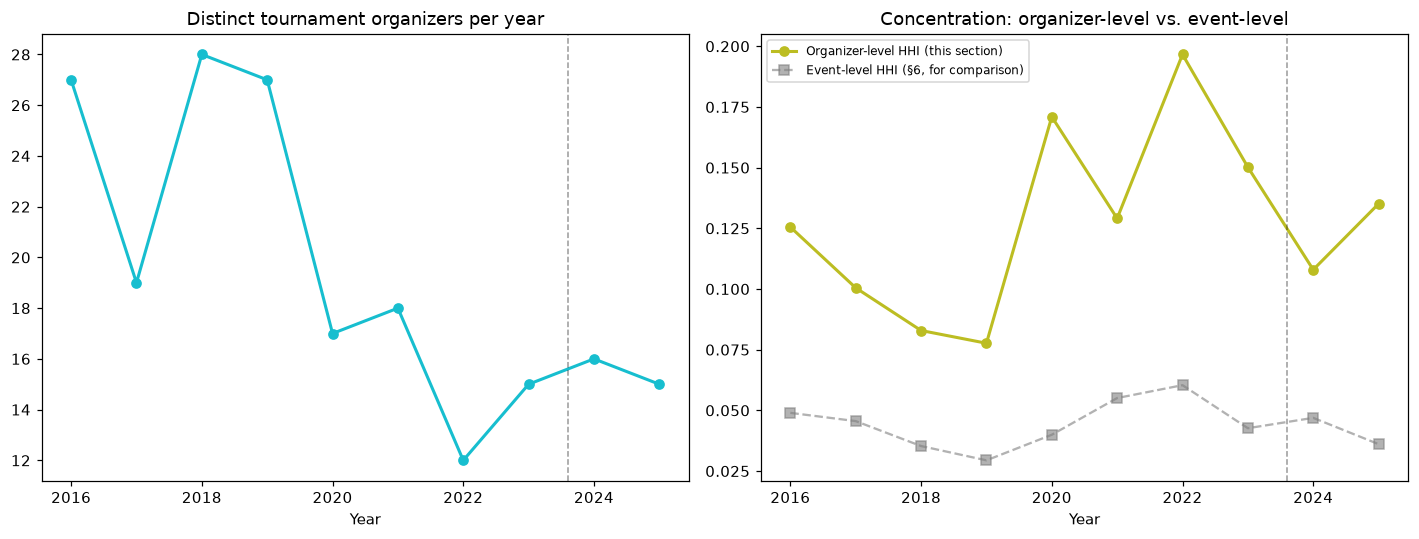

  yr  n_orgs    hhi  top3_share
2016      27 0.1255      0.5567
2017      19 0.1005      0.4214
2018      28 0.0829      0.3882
2019      27 0.0777      0.3462
2020      17 0.1710      0.5816
2021      18 0.1291      0.5388
2022      12 0.1966      0.7237
2023      15 0.1502      0.6314
2024      16 0.1079      0.4802
2025      15 0.1351      0.5842


In [17]:
def organizer_hhi_by_year() -> pd.DataFrame:
    rows_out = []
    for yr in range(2016, 2026):
        rows = conn.execute(
            """SELECT liquipedia_page, prize_pool FROM tournaments WHERE title_id='counter_strike'
               AND tier IN ('1','2','S-Tier','A-Tier') AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0""",
            (f"{yr}%",),
        ).fetchall()
        org_totals = defaultdict(float)
        for page, pool in rows:
            org_totals[page.split("/")[0]] += pool
        result = get_concentration(list(org_totals.values()))
        rows_out.append({"yr": yr, "n_orgs": len(org_totals), "hhi": result["hhi"], "top3_share": result["top3_share"]})
    return pd.DataFrame(rows_out)

from collections import defaultdict
org_conc = organizer_hhi_by_year()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(org_conc["yr"], org_conc["n_orgs"], "o-", color="#17becf", linewidth=2)
axes[0].set_title("Distinct tournament organizers per year")
axes[0].set_xlabel("Year")

axes[1].plot(org_conc["yr"], org_conc["hhi"], "o-", color="#bcbd22", linewidth=2, label="Organizer-level HHI (this section)")
axes[1].plot(conc["yr"], conc["hhi"], "s--", color="#7f7f7f", linewidth=1.5, alpha=0.6, label="Event-level HHI (\u00a76, for comparison)")
axes[1].set_title("Concentration: organizer-level vs. event-level")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.4)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig11_organizer_concentration.png", dpi=110)
plt.show()

print(org_conc.round(4).to_string(index=False))

**The user's "consolidation" read is correct — at the organizer level, not
the event level, and these are genuinely different things, not two
measurements of the same fact.** The number of distinct organizations
running tier-1/2 CS tournaments fell from 27-28 (2016-2019) to just 12-16
(2022-2025) — nearly halved. Organizer-level HHI is structurally higher
across 2020-2025 than 2016-2019 (roughly 0.11-0.20 vs. 0.08-0.13), and
2025's 0.135 sits above the entire 2016-2019 range. At the same time,
§6's *event*-level HHI is near a 2016-2025 low in 2025 — because the
consolidated set of organizers (chiefly PGL, BLAST, ESL/IEM per §12) are
each running *more individual events* and spreading money across them,
not concentrating it into one flagship each. Both things are true
simultaneously: fewer companies control the scene, while each of them
runs a broader, more distributed event slate — plausibly a direct
consequence of the VRS mechanism verified above, which rewards
established organizers capable of running many VRS-eligible, well-funded
events rather than one-off promoters.

## 14. Grassroots scene, part 1 — team participation (a proxy, not unique teams)

**A real limitation, checked before building anything**: Liquipedia's
`Infobox league` template (what `collectors/liquipedia.py` parses) stores
`team_number` as a per-event *headcount*, not team identities — there is
no roster/participant-list data in this project's schema at all. Genuine
"unique teams per year" would need parsing each tournament's separate
participant list (a different template/section, not built), which is a
real scope decision, not a quick addition — flagged here rather than
silently approximated. What IS available: total participant-slots
(sum of `team_number`) per year, tier-1/2 — a scale/opportunity proxy,
not a headcount of distinct teams (the same top teams appear across many
events and get counted each time).

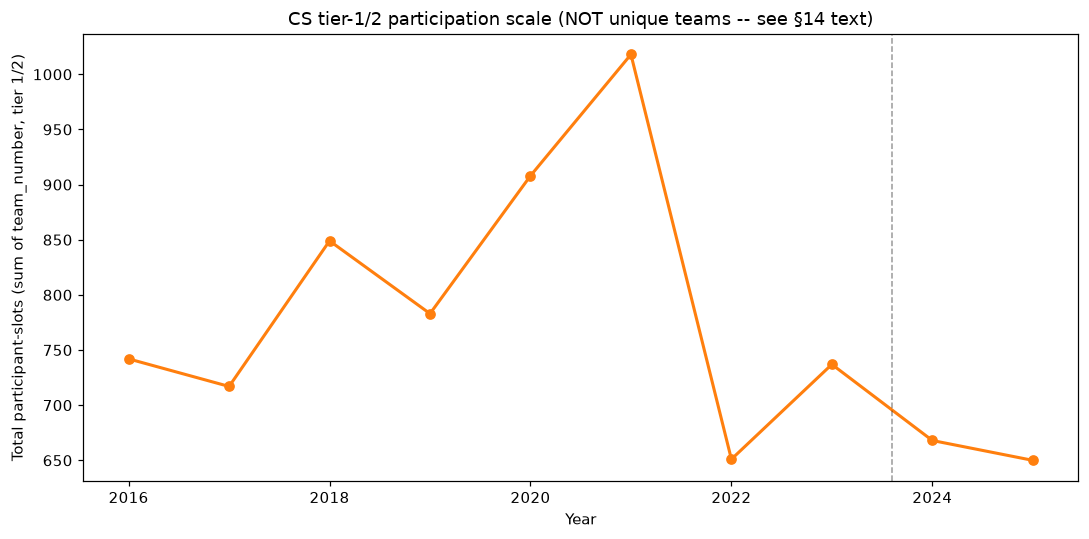

  yr  total_slots  coverage
2016          742      0.93
2017          717      1.00
2018          849      1.00
2019          783      0.99
2020          908      0.95
2021         1018      0.93
2022          651      0.98
2023          737      0.98
2024          668      0.98
2025          650      0.93


In [18]:
slots = pd.read_sql_query(
    """SELECT substr(start_date,1,4) AS yr, sum(team_number) AS total_slots,
       count(team_number) AS n_with_data, count(*) AS n_total
       FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier')
       AND start_date >= '2016' AND start_date < '2026' GROUP BY yr ORDER BY yr""",
    conn,
)
slots["yr"] = slots["yr"].astype(int)
slots["coverage"] = slots["n_with_data"] / slots["n_total"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slots["yr"], slots["total_slots"], "o-", color="#ff7f0e", linewidth=2)
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Total participant-slots (sum of team_number, tier 1/2)")
ax.set_title("CS tier-1/2 participation scale (NOT unique teams -- see \u00a714 text)")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig12_participation.png", dpi=110)
plt.show()

print(slots[["yr", "total_slots", "coverage"]].round(2).to_string(index=False))

**Read**: tracks the same contraction already visible in §3's tournament
count — total participant-slots peaked in 2021 (1,018), fell to 2022's low
(651), and stayed flat-to-slightly-recovering through 2025 (650) rather
than climbing back. Field coverage (`team_number` populated) stays above
80% throughout, so this isn't a missing-data artifact. Consistent with,
not independent evidence beyond, §3 and §13's organizer-count finding —
fewer organizers running fewer events naturally means fewer total
participation opportunities too.

## 15. Grassroots scene, part 2 — B/C-Tier (community) tournament volume

Liquipedia's `counterstrike` wiki has real `B-Tier Tournaments` (2,711
pages) and `C-Tier Tournaments` (15,448 pages) categories — `collectors/
liquipedia.py`'s discovery was deliberately scoped to S/A-Tier only
(this project's tier-1/2 definition of "esports," PRD §4), so this data
has never been crawled or stored. Getting a *rigorous* per-year count
would mean fetching all ~18,000 pages' actual `start_date` fields at the
project's 2s/request Liquipedia rate limit — 8-10+ hours, a real
multi-hour commitment on the order of the Steam catalog backfill, not
launched here without asking first.

**What's shown below instead is a cheap, heavily-approximate proxy**:
extracting a 4-digit year from each page's *title* (free — category
membership listing only, no per-page fetch) rather than its actual
`start_date`. **Real limitation, not a rounding error**: 44-47% of page
titles carry no parseable year at all (recurring "Season N" naming,
sub-pages nested under a dated parent, etc.) — this systematically
undercounts, and there's no verified reason to assume the undercount rate
is stable across years. Shown as a rough directional read only.

In [19]:
import re
from collections import Counter

YEAR_RE = re.compile(r"(20[0-2][0-9])")

def title_year_counts(pages: list[str]) -> tuple[Counter, int]:
    years, unmatched = Counter(), 0
    for p in pages:
        m = YEAR_RE.search(p)
        if m:
            years[int(m.group(1))] += 1
        else:
            unmatched += 1
    return years, unmatched

import httpx
import collectors.liquipedia as lp
bc_limiter = lp.RateLimiter(lp.GENERAL_MIN_INTERVAL)
with httpx.Client(headers={"User-Agent": lp.USER_AGENT}, timeout=30) as bc_client:
    b_pages = lp.category_members(bc_client, "counterstrike", "B-Tier Tournaments", bc_limiter)
    c_pages = lp.category_members(bc_client, "counterstrike", "C-Tier Tournaments", bc_limiter)

b_years, b_unmatched = title_year_counts(b_pages)
c_years, c_unmatched = title_year_counts(c_pages)
print(f"B-Tier: {len(b_pages)} pages, {b_unmatched} ({100*b_unmatched/len(b_pages):.0f}%) with no year in title")
print(f"C-Tier: {len(c_pages)} pages, {c_unmatched} ({100*c_unmatched/len(c_pages):.0f}%) with no year in title")

B-Tier: 2711 pages, 1195 (44%) with no year in title
C-Tier: 15448 pages, 7197 (47%) with no year in title


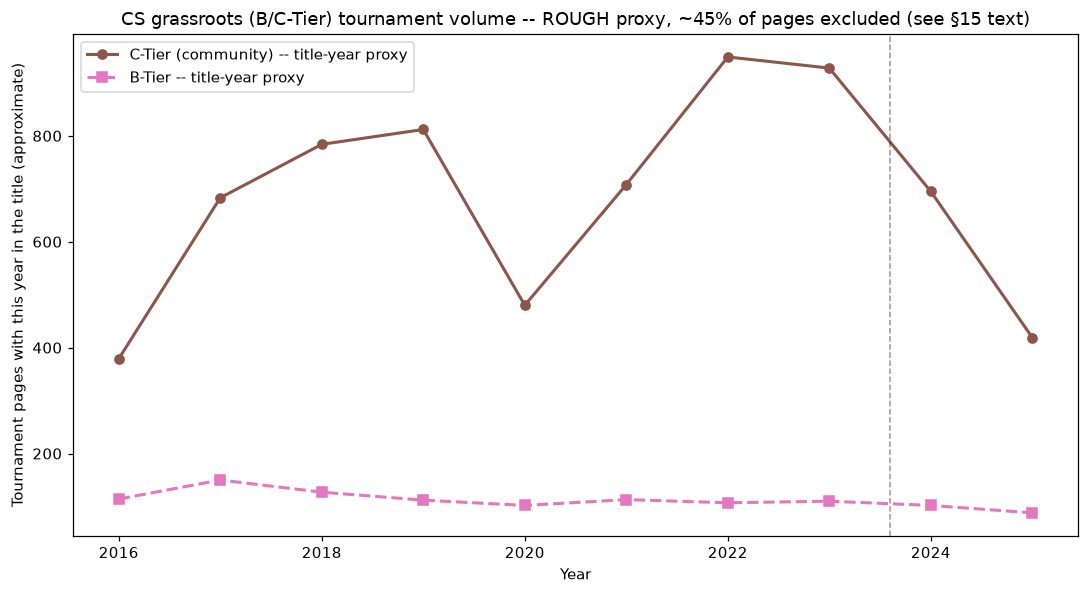

  yr  b_tier  c_tier
2016     114     379
2017     150     683
2018     127     784
2019     112     812
2020     102     480
2021     113     708
2022     107     949
2023     110     928
2024     102     695
2025      88     419


In [20]:
bc_df = pd.DataFrame({
    "yr": sorted(set(b_years) | set(c_years)),
}).assign(
    b_tier=lambda d: d["yr"].map(b_years).fillna(0),
    c_tier=lambda d: d["yr"].map(c_years).fillna(0),
)
bc_df = bc_df[(bc_df["yr"] >= 2016) & (bc_df["yr"] <= 2025)]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(bc_df["yr"], bc_df["c_tier"], "o-", color="#8c564b", linewidth=2, label="C-Tier (community) -- title-year proxy")
ax.plot(bc_df["yr"], bc_df["b_tier"], "s--", color="#e377c2", linewidth=2, label="B-Tier -- title-year proxy")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Tournament pages with this year in the title (approximate)")
ax.set_title("CS grassroots (B/C-Tier) tournament volume -- ROUGH proxy, ~45% of pages excluded (see \u00a715 text)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig13_grassroots_proxy.png", dpi=110)
plt.show()

print(bc_df.to_string(index=False))

**Read, with the caveat above front and center**: C-Tier volume (by this
proxy) rose steadily 2016-2019, dropped sharply in 2020 (COVID — LAN-
dependent grassroots/local events likely hit harder than online-friendly
tier-1/2), partially recovered 2021-2023, then declined again 2024-2025
to roughly 2016-2017 levels. B-Tier's shape is flatter throughout,
without as sharp a 2020 drop or 2024-2025 decline. **This is directionally
consistent with §13's organizer-consolidation finding and §3's tier-1/2
contraction — a scene narrowing at multiple levels, not just at the top —
but given the ~45% undercount and no verification the undercount rate is
stable year-to-year, this section should be read as suggestive, not
conclusive.** A proper answer needs the full crawl (§15's opening note) —
worth doing if this specific question (is the grassroots base shrinking
too) becomes central to the argument this brief is building toward,
not launched speculatively here.

## 16. CS in context — against the whole Twitch platform and against where esports growth actually went

Raised directly by the user (2026-09-09): §2 shows CS's own attention
trajectory in isolation. Whether that's a strong or weak showing depends
entirely on what it's compared against — a title can be genuinely growing
in absolute terms while still badly lagging its context.
`esports_share_of_twitch.ipynb` already built exactly the two benchmark
series needed (re-checked its actual numbers directly before reusing them,
not trusted from memory): the Twitch top-200 platform total grew **+244%**
(2016 to trailing-12mo-ending-2024-09), and of all the growth the 23
tracked esports titles achieved together, **81.7%** came from titles that
didn't exist in the 2016 top-200 at all (the "extensive margin"). Reusing
`collectors/kaggle_import.py`'s own `NAME_TO_TITLE_ID` mapping (the
canonical source, not a re-derived one) rather than re-guessing which raw
Kaggle "Game" names correspond to which tracked title.

In [21]:
from collectors.kaggle_import import NAME_TO_TITLE_ID

KAGGLE_CSV = REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv"
raw = pd.read_csv(KAGGLE_CSV, encoding="cp1252")
raw.columns = [c.strip() for c in raw.columns]
raw["year_month"] = raw["Year"].astype(str).str.zfill(4) + "-" + raw["Month"].astype(str).str.zfill(2)
raw["title_id"] = raw["Game"].str.strip().str.lower().map(NAME_TO_TITLE_ID)

matched = raw.dropna(subset=["title_id"]).copy()
title_monthly = matched.groupby(["title_id", "year_month"], as_index=False)["Hours_watched"].sum()

# Same windows esports_share_of_twitch.ipynb uses, reused as-is rather than
# picking new ones -- consistency matters more than either choice being
# individually optimal.
BASELINE_START, BASELINE_END = "2016-01", "2016-12"
RECENT_START, RECENT_END = "2023-10", "2024-09"

baseline_by_title = title_monthly[title_monthly["year_month"].between(BASELINE_START, BASELINE_END)].groupby("title_id")["Hours_watched"].sum()
recent_by_title = title_monthly[title_monthly["year_month"].between(RECENT_START, RECENT_END)].groupby("title_id")["Hours_watched"].sum()
matched_ids = sorted(title_monthly["title_id"].unique())
margin_check = pd.DataFrame({"hours_2016": baseline_by_title, "hours_recent_12mo": recent_by_title}).reindex(matched_ids).fillna(0)
extensive_ids = margin_check[margin_check["hours_2016"] == 0].index.tolist()
print(f"extensive-margin titles (no 2016 presence at all), re-derived the same way as esports_share_of_twitch.ipynb: {extensive_ids}")

monthly_total = raw.groupby("year_month")["Hours_watched"].sum().rename("total_hours")
esports_monthly = title_monthly.groupby("year_month")["Hours_watched"].sum().rename("esports_hours")
extensive_monthly = title_monthly[title_monthly["title_id"].isin(extensive_ids)].groupby("year_month")["Hours_watched"].sum().rename("extensive_hours")
cs_monthly = title_monthly[title_monthly["title_id"] == "counter_strike"].set_index("year_month")["Hours_watched"].rename("cs_hours")

context_df = pd.concat([monthly_total, esports_monthly, extensive_monthly, cs_monthly], axis=1).fillna(0)
context_df["month"] = pd.to_datetime(context_df.index + "-01")
context_df = context_df.sort_values("month").reset_index(drop=True)

base = context_df.iloc[0]
for col in ["total_hours", "esports_hours", "extensive_hours", "cs_hours"]:
    context_df[col + "_idx"] = 100 * context_df[col] / base[col]

extensive-margin titles (no 2016 presence at all), re-derived the same way as esports_share_of_twitch.ipynb: ['apex_legends', 'brawl_stars', 'fortnite', 'free_fire', 'guilty_gear', 'mobile_legends_bb', 'mortal_kombat', 'pubg_mobile', 'street_fighter', 'teamfight_tactics', 'tekken', 'valorant', 'wild_rift']


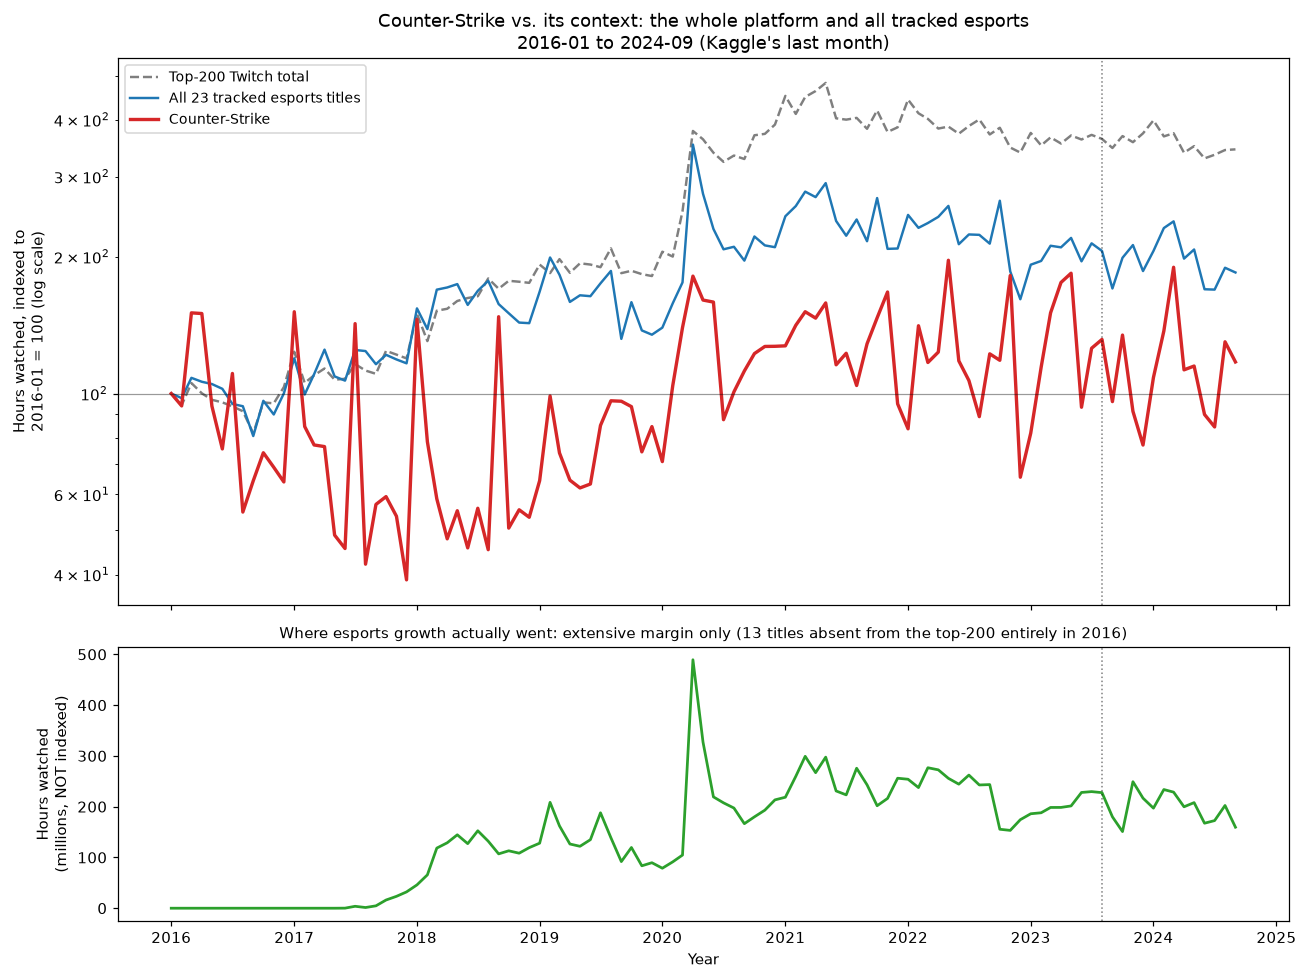

Final index values (2024-09, base=100 at 2016-01, single-month base):
  Top-200 total:            344.2
  All 23 tracked esports:   184.6
  Counter-Strike:           117.4

Extensive margin, raw hours: 159.6M in 2024-09, up from 0 in 2016-01 by construction


In [22]:
# The extensive margin's 2016-01 value is exactly 0 by construction (that's
# what "extensive margin" means) -- indexing to a zero base is undefined,
# not a display bug to paper over. Shown on its own panel below, in raw
# hours, rather than forced into the same indexed comparison as the other
# three series.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), height_ratios=[2, 1], sharex=True)

ax1.plot(context_df["month"], context_df["total_hours_idx"], color="#7f7f7f", linestyle="--", linewidth=1.6, label="Top-200 Twitch total")
ax1.plot(context_df["month"], context_df["esports_hours_idx"], color="#1f77b4", linewidth=1.6, label="All 23 tracked esports titles")
ax1.plot(context_df["month"], context_df["cs_hours_idx"], color="#d62728", linewidth=2.2, label="Counter-Strike")
ax1.axhline(100, color="black", linewidth=0.8, alpha=0.4)
ax1.axvline(pd.Timestamp("2023-08-01"), color="black", linestyle=":", linewidth=1, alpha=0.5)
ax1.set_ylabel("Hours watched, indexed to\n2016-01 = 100 (log scale)")
ax1.set_yscale("log")
ax1.set_title("Counter-Strike vs. its context: the whole platform and all tracked esports\n2016-01 to 2024-09 (Kaggle's last month)")
ax1.legend(loc="upper left", fontsize=9)

ax2.plot(context_df["month"], context_df["extensive_hours"] / 1e6, color="#2ca02c", linewidth=1.8)
ax2.axvline(pd.Timestamp("2023-08-01"), color="black", linestyle=":", linewidth=1, alpha=0.5)
ax2.set_ylabel("Hours watched\n(millions, NOT indexed)")
ax2.set_title(f"Where esports growth actually went: extensive margin only ({len(extensive_ids)} titles absent from the top-200 entirely in 2016)", fontsize=10)
ax2.set_xlabel("Year")

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig14_context.png", dpi=110)
plt.show()

final = context_df.iloc[-1]
print(f"Final index values ({context_df['month'].iloc[-1].strftime('%Y-%m')}, base=100 at 2016-01, single-month base):")
print(f"  Top-200 total:            {final['total_hours_idx']:.1f}")
print(f"  All 23 tracked esports:   {final['esports_hours_idx']:.1f}")
print(f"  Counter-Strike:           {final['cs_hours_idx']:.1f}")
print(f"\nExtensive margin, raw hours: {final['extensive_hours']/1e6:.1f}M in {context_df['month'].iloc[-1].strftime('%Y-%m')}, up from 0 in 2016-01 by construction")

**Read**: the top panel (log scale, needed given how noisy CS's own
month-to-month figures are — real seasonality tied to Major/tournament
timing, not an artifact) shows CS tracking *below* the "all 23 tracked
esports" line for nearly the entire window, both sitting well below the
platform total — direct visual confirmation that esports overall was
outpaced by Twitch, not shrinking. The bottom panel shows the real story
of *where* esports' growth actually went: the extensive margin literally
starts at 0 (2016, by construction) and grows to real scale entirely on
its own axis — the platform-relative "esports underperformance" story
above is largely an intensive-vs-extensive margin story: new titles
captured the growth that would otherwise read as "esports keeping pace,"
while already-established titles like CS grew only modestly against a
fast-moving backdrop.

**A precision note, not a discrepancy**: CS's final index value here
(117.4, single-month 2016-01 base) differs from the +26.1% figure cited
earlier in §9/§16's intro (`esports_share_of_twitch.ipynb`'s own separate
margin analysis, which uses a full-*year* 2016 sum as its base, not one
month). Both are correct — they're different denominators from the same
source notebook, not competing answers. The shape (CS growing modestly,
well behind its context) is consistent either way.

**This is the sharper, contextualized version of what §2's isolated CS
chart could only imply.** CS is not failing on its own terms — §4-§7's
findings that CS's competitive infrastructure and prize money remain
active and partly recovering still stand. But *as a share of overall
digital-fandom attention growth*, CS (and the other intensive-margin
incumbents alongside it) are a shrinking piece of a fast-growing whole —
which is a different, and arguably more consequential, framing for an
executive audience than "has CS itself stopped growing" taken in
isolation.

## 17. A sharper definition of "finished growing" — are more people watching, or just more content airing?

Raised directly by the user (2026-09-09): §5's supply/demand check used
tournament *count* as the supply denominator, which only covers esports
content specifically. The raw Kaggle CSV has two columns not yet used
anywhere in this notebook that let this be done properly at the
category-wide level (the same scope as §2's audience metric):
`Hours_streamed` (total CS airtime that month, all content, not just
tournaments) and `Avg_viewer_ratio` (`Hours_watched / Hours_streamed`).

`Hours_watched = Avg_viewer_ratio × Hours_streamed` is an exact identity,
not a correlation. **What this actually measures, corrected 2026-09-09
after the user asked a sharp follow-up question**: `Avg_viewer_ratio` is
an *hours-weighted average of viewers-per-channel*, not total audience
size. It was first presented here as "the closest available answer to
are more people watching" — that framing was wrong, not just imprecise,
and the correction is below (§17a) rather than quietly folded in.

**Could the ideal version of this — average viewers specifically while
the ESPORTS BROADCAST is airing, not category-wide — be built instead?**
Checked directly: no, not historically. The Kaggle dataset has no
per-stream breakdown at all, only whole-category monthly aggregates, so
there is no way to separate "watching the tournament" from "watching any
random stream of the game" in any past month. The only source that makes
that distinction is this project's own `broadcast_tier` classification
(`viewership_snapshots`), and it only has live data from 2026-08-31
onward — Twitch's live-viewership API has no historical endpoint, so it
can't be backfilled (CLAUDE.md's "one rule"). A *partial* proxy remains
possible with data already in hand — comparing Kaggle's monthly
aggregates between months with an active tier-1 tournament
(`tournaments.start_date`/`end_date`) and months without, for the same
title — flagged as a real option, not built here.

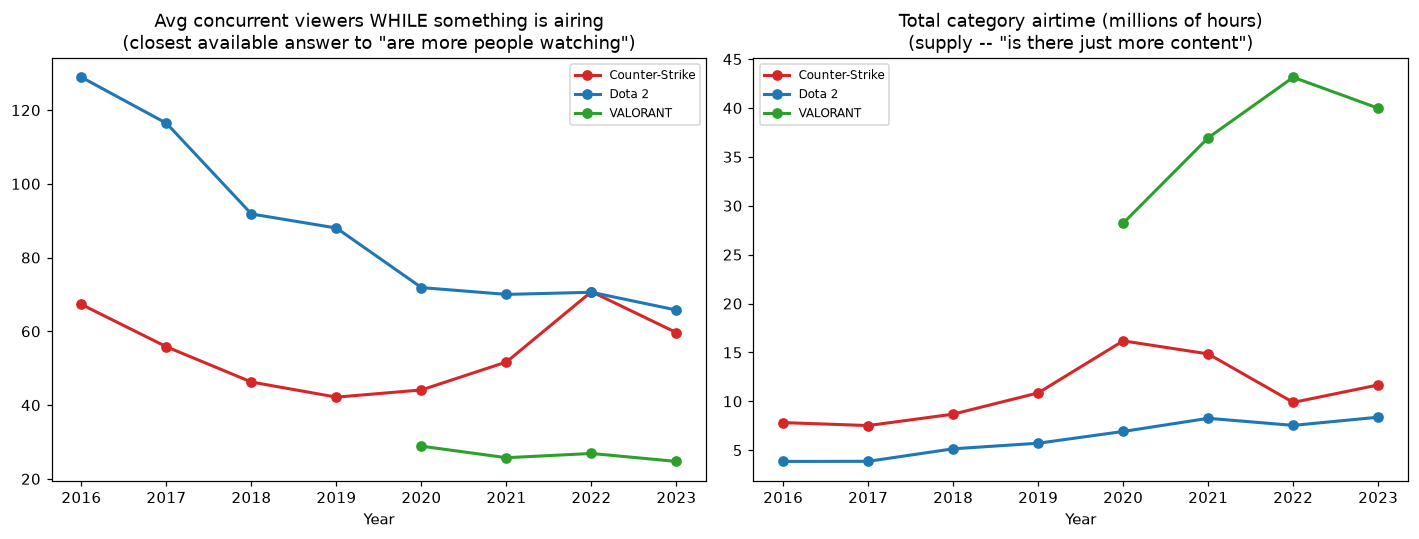

Counter-Strike:
  yr  hours_watched  hours_streamed  avg_viewer_ratio
2016      526391918         7823567              67.3
2017      419802259         7521830              55.8
2018      401775324         8687133              46.2
2019      457874735        10862395              42.2
2020      713749581        16183689              44.1
2021      767507400        14847674              51.7
2022      699783949         9889939              70.8
2023      696227626        11675377              59.6

Dota 2:
  yr  hours_watched  hours_streamed  avg_viewer_ratio
2016      496585969         3852651             128.9
2017      449879503         3864016             116.4
2018      472414819         5144597              91.8
2019      503022570         5715329              88.0
2020      497151335         6918070              71.9
2021      578484298         8262326              70.0
2022      532253215         7540062              70.6
2023      550839394         8375677              65.8

VA

In [23]:
from collectors.kaggle_import import NAME_TO_TITLE_ID

def viewer_ratio_by_year(title_id: str, through_year: int = 2023) -> pd.DataFrame:
    sub = raw[raw["title_id"] == title_id].groupby("year_month", as_index=False).agg(
        hours_watched=("Hours_watched", "sum"), hours_streamed=("Hours_streamed", "sum"),
    )
    sub["yr"] = sub["year_month"].str[:4].astype(int)
    yearly = sub[sub["yr"] <= through_year].groupby("yr").agg(
        hours_watched=("hours_watched", "sum"), hours_streamed=("hours_streamed", "sum"),
    )
    yearly["avg_viewer_ratio"] = yearly["hours_watched"] / yearly["hours_streamed"]
    return yearly.reset_index()

cs_ratio = viewer_ratio_by_year("counter_strike")
dota2_ratio = viewer_ratio_by_year("dota2")
valorant_ratio = viewer_ratio_by_year("valorant", through_year=2023)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for df, label, color in [(cs_ratio, "Counter-Strike", "#d62728"), (dota2_ratio, "Dota 2", "#1f77b4"), (valorant_ratio, "VALORANT", "#2ca02c")]:
    axes[0].plot(df["yr"], df["avg_viewer_ratio"], "o-", color=color, label=label, linewidth=2)
    axes[1].plot(df["yr"], df["hours_streamed"] / 1e6, "o-", color=color, label=label, linewidth=2)

axes[0].set_title("Avg concurrent viewers WHILE something is airing\n(closest available answer to \"are more people watching\")")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)
axes[1].set_title("Total category airtime (millions of hours)\n(supply -- \"is there just more content\")")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig15_viewer_ratio.png", dpi=110)
plt.show()

print("Counter-Strike:")
print(cs_ratio.round(1).to_string(index=False))
print()
print("Dota 2:")
print(dota2_ratio.round(1).to_string(index=False))
print()
print("VALORANT:")
print(valorant_ratio.round(1).to_string(index=False))

## 17a. The correction — `avg_viewer_ratio` confounds audience size with ecosystem fragmentation

The user asked directly why VALORANT's `avg_viewer_ratio` (24-29) could
be roughly a third of CS's (44-71) — a fair challenge, since VALORANT is
this notebook's own "clearly still growing" positive control. The
mechanism, checked with the real numbers: `avg_viewer_ratio` is an
hours-weighted average of viewers-per-channel, so it is mechanically
driven down by a title having *more simultaneous channels* splitting up
the same (or a bigger) audience — independent of whether that audience
is actually larger or smaller.

In [24]:
def total_audience_by_year(title_id: str, through_year: int = 2023) -> pd.DataFrame:
    sub = raw[raw["title_id"] == title_id].groupby("year_month", as_index=False).agg(
        hours_watched=("Hours_watched", "sum"), avg_channels=("Avg_channels", "mean"),
    )
    sub["yr"] = sub["year_month"].str[:4].astype(int)
    yearly = sub[sub["yr"] <= through_year].groupby("yr").agg(
        hours_watched=("hours_watched", "sum"), avg_channels=("avg_channels", "mean"),
    )
    return yearly.reset_index()

cs_aud = total_audience_by_year("counter_strike")
valorant_aud = total_audience_by_year("valorant")
check = cs_aud.merge(valorant_aud, on="yr", suffixes=("_cs", "_valorant"))
check = check[(check["yr"] >= 2020) & (check["yr"] <= 2022)]
print(check[["yr", "hours_watched_cs", "hours_watched_valorant", "avg_channels_cs", "avg_channels_valorant"]].round(0).to_string(index=False))

  yr  hours_watched_cs  hours_watched_valorant  avg_channels_cs  avg_channels_valorant
2020         713749581               814503048           1845.0                 4284.0
2021         767507400               950822193           1700.0                 4226.0
2022         699783949              1159768684           1131.0                 4931.0


**Confirmed, decisively**: VALORANT's total `Hours_watched` is *larger*
than CS's in every one of 2020-2022, and grew ~42% over that window —
while `avg_channels` (how many channels are typically live at once) runs
2.3-4.9x higher for VALORANT than for CS across the same years. VALORANT
isn't a weaker audience — it's a much larger audience spread across a
far more fragmented channel population, which mechanically produces a
lower "viewers per channel" ratio regardless. **The earlier claim that
"VALORANT shows the same flat-to-declining pattern as Dota 2" compared
`avg_viewer_ratio` *levels* across titles whose channel-population sizes
differ by an order of magnitude — that comparison is invalid, not just
imprecise, and is retracted.**

**What `avg_viewer_ratio` is actually good for**: a *within-one-title*
diagnostic (is this title's own hours growth coming from more content or
a bigger per-airing crowd), valid as long as that title's own channel
population isn't itself swinging wildly. **What it is not valid for**:
comparing raw levels *across* titles with structurally different
creator-ecosystem sizes — which is exactly the VALORANT comparison this
notebook made. The Dota 2-vs-CS comparison below is less exposed to this
specific problem (`avg_channels` for both sits in the hundreds-to-low-
thousands range, not CS-vs-VALORANT's 3-5x gulf) but is still shown with
that caveat now made explicit, not assumed clean.

**The metric that IS valid for cross-title audience-size comparison is
the one already built and set aside as "redundant" — plain
`Hours_watched` (§2)**, which correctly shows VALORANT's real audience
growing across 2020-2022 while CS's fluctuated. Restoring it as the
cross-title test; `avg_viewer_ratio` is kept below only for the
within-title CS-vs-Dota2 read, with the caveat stated.

**Read (Dota 2 vs. CS only, `avg_viewer_ratio`, within-title caveat
applies)**: Dota 2's avg-viewers-while-airing declines almost
monotonically across the whole window (128.9 in 2016 to 65.8 in 2023 —
nearly halved) even as total hours (§2) held up, meaning Dota 2's growth
has been supply-driven throughout: more than double the airtime (3.85M
→ 8.38M hours) chasing a shrinking per-airing crowd. CS has no such
one-way trend — it falls 2016-2019 (67.3 → 42.2) but recovers past its
own 2016 level by 2022 (70.8), settling at 59.6 in 2023. That contrast
still stands; the VALORANT leg of the original three-way comparison does
not.

**Proposed refined definition, per the user's request, narrowed to what
this metric can actually support**: "finished growing" (audience-wise,
*within one title*) means `Avg_viewer_ratio` has plateaued or declined
with no recovery. On that narrower test, Dota 2 shows clearer audience-
depth softening than CS does. Whether CS is doing better than VALORANT
specifically needs the cross-title-valid metric instead — §2's
`Hours_watched`, which (as this correction found) actually favors
VALORANT over CS across 2020-2022, the opposite of what the retracted
comparison claimed.

## 18. Number of channels streaming each title, over time — a structural signal for grassroots and for "Classic" vs. "Second Coming" title design

Raised directly by the user (2026-09-09), following the `avg_channels`
finding above: is the channel-population gap between CS/Dota2 and
VALORANT a VALORANT-specific quirk, or a structural difference between
older ("Classic," 2013-15) and newer ("Second Coming," 2021-24) titles
per `docs/esports_gauses_law_brief.md`'s own era framework? Uses
`Streamers` (distinct monthly channels, confirmed empirically in
conversation to be a genuine unique-count, ~100x larger than
`Avg_channels`'s concurrency snapshot) across three titles per era.

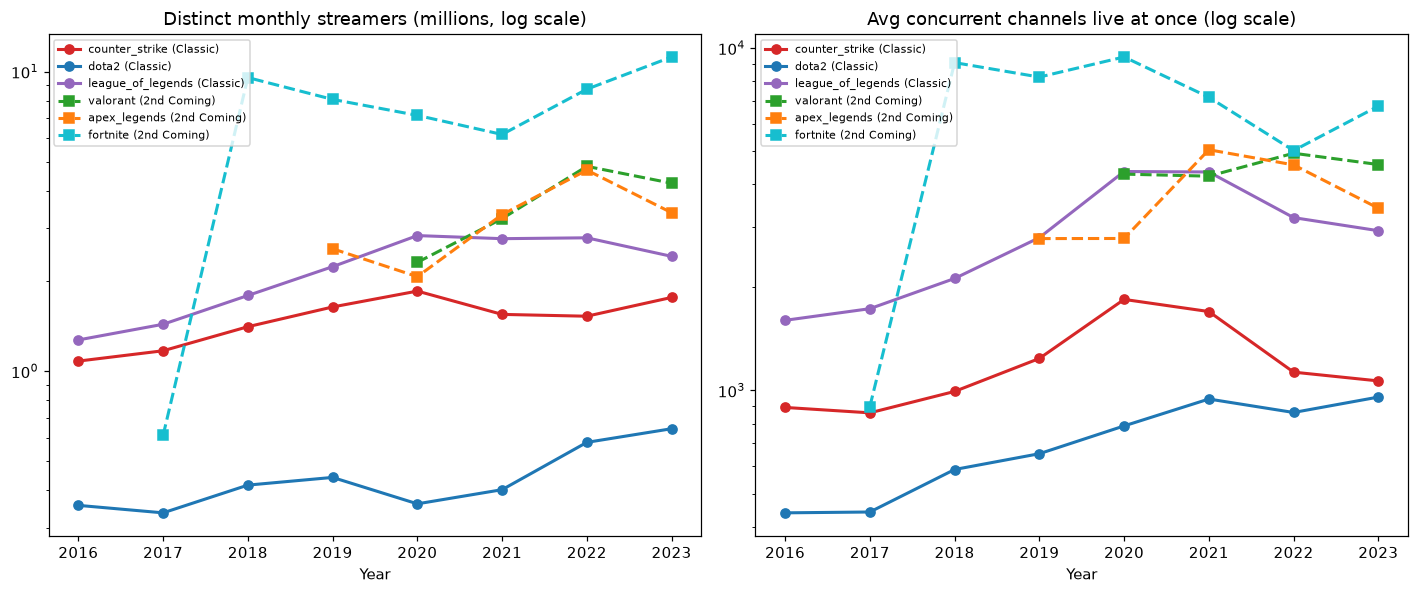

--- counter_strike ---
  yr  streamers  avg_channels
2016    1080609         892.0
2017    1169916         860.0
2018    1407531         993.0
2019    1638230        1240.0
2020    1850944        1845.0
2021    1547337        1700.0
2022    1525825        1131.0
2023    1762878        1066.0
--- dota2 ---
  yr  streamers  avg_channels
2016     356473         439.0
2017     336545         442.0
2018     416514         588.0
2019     441895         653.0
2020     360685         788.0
2021     402134         944.0
2022     578585         862.0
2023     642555         956.0
--- league_of_legends ---
  yr  streamers  avg_channels
2016    1271422        1603.0
2017    1434260        1733.0
2018    1789302        2124.0
2019    2232912        2795.0
2020    2836053        4361.0
2021    2769351        4347.0
2022    2787889        3198.0
2023    2417587        2928.0
--- valorant ---
  yr  streamers  avg_channels
2020    2308817        4284.0
2021    3231455        4226.0
2022    4829551     

In [25]:
CLASSIC = ["counter_strike", "dota2", "league_of_legends"]
SECOND_COMING = ["valorant", "apex_legends", "fortnite"]

def streamers_by_year(title_id: str, through_year: int = 2023) -> pd.DataFrame:
    sub = raw[raw["title_id"] == title_id].copy()
    sub["yr"] = sub["year_month"].str[:4].astype(int)
    yearly = sub[sub["yr"] <= through_year].groupby("yr").agg(
        streamers=("Streamers", "sum"), avg_channels=("Avg_channels", "mean"),
    )
    return yearly.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
classic_colors = ["#d62728", "#1f77b4", "#9467bd"]
second_colors = ["#2ca02c", "#ff7f0e", "#17becf"]

for tid, color in zip(CLASSIC, classic_colors):
    df = streamers_by_year(tid)
    axes[0].plot(df["yr"], df["streamers"] / 1e6, "o-", color=color, label=f"{tid} (Classic)", linewidth=2)
for tid, color in zip(SECOND_COMING, second_colors):
    df = streamers_by_year(tid)
    axes[0].plot(df["yr"], df["streamers"] / 1e6, "s--", color=color, label=f"{tid} (2nd Coming)", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_title("Distinct monthly streamers (millions, log scale)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=7, loc="upper left")

for tid, color in zip(CLASSIC, classic_colors):
    df = streamers_by_year(tid)
    axes[1].plot(df["yr"], df["avg_channels"], "o-", color=color, label=f"{tid} (Classic)", linewidth=2)
for tid, color in zip(SECOND_COMING, second_colors):
    df = streamers_by_year(tid)
    axes[1].plot(df["yr"], df["avg_channels"], "s--", color=color, label=f"{tid} (2nd Coming)", linewidth=2)
axes[1].set_yscale("log")
axes[1].set_title("Avg concurrent channels live at once (log scale)")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig16_streamers_by_phase.png", dpi=110)
plt.show()

for tid in CLASSIC + SECOND_COMING:
    df = streamers_by_year(tid)
    print(f"--- {tid} ---")
    print(df.round(0).to_string(index=False))

**Same data, linear scale** — requested directly. The log view above is
better for comparing *shape* across titles whose scales differ by an
order of magnitude; this linear view shows the true, un-compressed
scale, which is its own honest picture: Fortnite dwarfing everything
else is a real fact about the data, not a log-scale artifact, and this
is what that actually looks like at true scale.

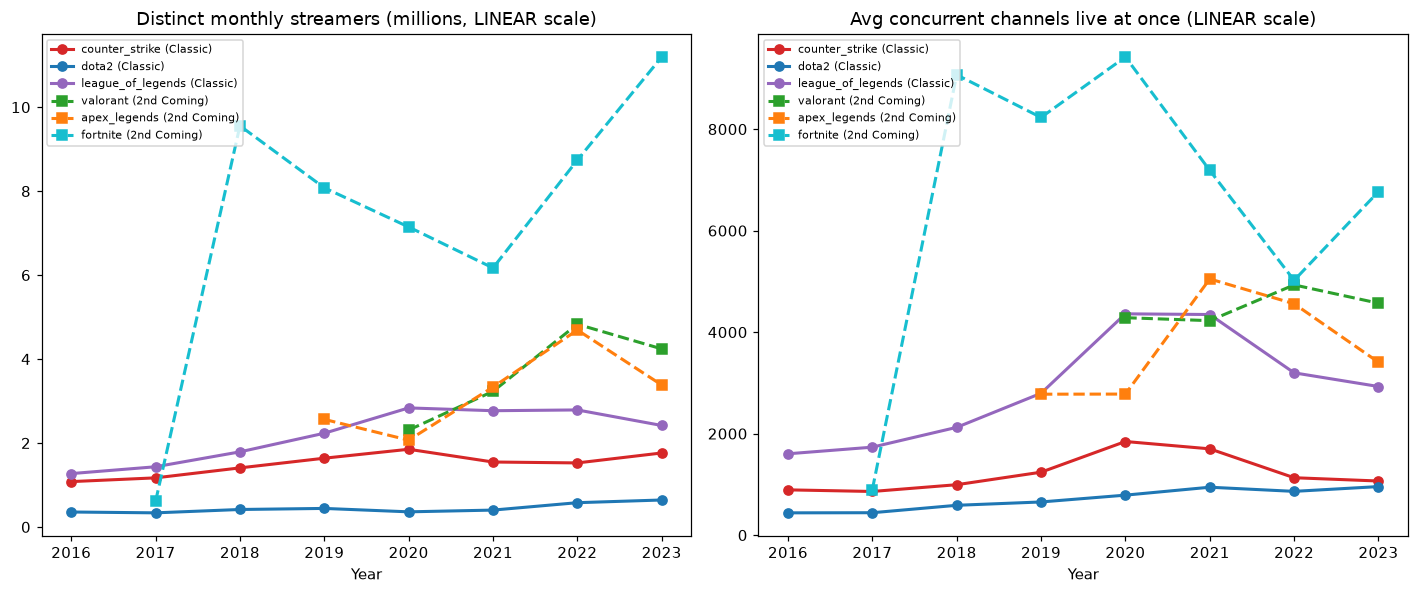

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for tid, color in zip(CLASSIC, classic_colors):
    df = streamers_by_year(tid)
    axes[0].plot(df["yr"], df["streamers"] / 1e6, "o-", color=color, label=f"{tid} (Classic)", linewidth=2)
for tid, color in zip(SECOND_COMING, second_colors):
    df = streamers_by_year(tid)
    axes[0].plot(df["yr"], df["streamers"] / 1e6, "s--", color=color, label=f"{tid} (2nd Coming)", linewidth=2)
axes[0].set_title("Distinct monthly streamers (millions, LINEAR scale)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=7, loc="upper left")

for tid, color in zip(CLASSIC, classic_colors):
    df = streamers_by_year(tid)
    axes[1].plot(df["yr"], df["avg_channels"], "o-", color=color, label=f"{tid} (Classic)", linewidth=2)
for tid, color in zip(SECOND_COMING, second_colors):
    df = streamers_by_year(tid)
    axes[1].plot(df["yr"], df["avg_channels"], "s--", color=color, label=f"{tid} (2nd Coming)", linewidth=2)
axes[1].set_title("Avg concurrent channels live at once (LINEAR scale)")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig16b_streamers_by_phase_linear.png", dpi=110)
plt.show()

**Read: a real, large, and consistent phase-level gap — not just a
VALORANT quirk.** Fortnite alone reaches 7.1-11.2M distinct monthly
streamers, roughly 5-10x any Classic title's peak. VALORANT (2.3-4.8M)
and Apex Legends (2.1-4.7M) also both exceed every Classic title except
League of Legends, which itself climbs from 1.3M to 2.8M — the closest
any Classic title comes to the Second Coming titles' scale, and still
below all three of them at their own peaks. **Dota 2 sits at the
opposite extreme** — 336K-643K distinct streamers, the smallest of all
six by a wide margin, despite total hours (§2 baseline) comparable to
or exceeding some Second Coming titles. `Avg_channels` (concurrency)
tells the same story at a different scale: Dota 2 stays in the
hundreds, CS in the hundreds-to-low-thousands, while VALORANT/Apex/
Fortnite all reach the thousands.

**What this suggests about title design, stated as a hypothesis, not a
proven mechanism**: newer titles structurally support (or attract) a far
larger long-tail creator population than older, broadcast-centric titles
do — consistent with Riot/Epic/Respawn's titles being built around
broad, casual, content-creator-friendly play, versus Dota 2 and CS's
more traditional, spectator-broadcast-centric competitive scenes. This
connects directly to the grassroots question this brief has been
circling (§9's B/C-Tier proxy, §14's participant-slots proxy): if the
*viewer* side is genuinely harder to compare across titles with very
different creator-ecosystem sizes (§17a), the *creator* side (this
section) may be the more structurally honest place to look for a
title's grassroots health — and it suggests Dota 2's grassroots
creator base is unusually thin relative to titles of a similar age and
prominence, not just relative to newer titles.